# Total Points Modeling

This notebook creates total-points modeling using the refined fixture table in BigQuery.

In [1]:
import sys
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, PoissonRegressor, Ridge, TweedieRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from injestion.core.bq import get_client

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

try:
    import statsmodels.api as sm  # noqa: F401
    HAS_STATSMODELS = True
except ModuleNotFoundError:
    HAS_STATSMODELS = False

In [2]:
bq_client = get_client()

table_id = "prizepicksanalytics.originations_tennis.refined_fixture_stats"
query = f"SELECT * FROM `{table_id}`"

fixture_df = bq_client.query(query).to_dataframe()
print(f"Rows fetched: {len(fixture_df):,}")
print(f"Columns fetched: {len(fixture_df.columns)}")
fixture_df.head()

Rows fetched: 6,239
Columns fetched: 31


,sport_event_id,total_points,total_rows_in_pbp,point_rows,period_score_rows,total_serve_holds,total_serve_breaks,first_event_time,last_event_time,mode_best_of,total_sets,match_status,home_competitor_id,away_competitor_id,home_competitor_name,away_competitor_name,total_games_played,total_tiebreaks_played,summary_competition_type,summary_match_status,summary_home_sets,summary_away_sets,summary_mode_best_of,period_score_matches_total_games,break_rate,min_possible_points,violates_min_points,total_aces_match,serve_stats_rows,non_null_ace_rows,ace_rate
0,sr:sport_event:58213339,74,79,62,12,6,6,2025-03-02 23:11:15+00:00,2025-03-03 00:07:51+00:00,3,2,ended,sr:competitor:228418,sr:competitor:208105,"Navarro, Emma","Arango, Emiliana",12,0,singles,ended,2,0,3,True,0.5,48,False,0.0,2,2,0.000000
1,sr:sport_event:58906357,67,72,55,12,6,6,2025-03-20 17:51:32+00:00,2025-03-20 18:40:16+00:00,3,2,ended,sr:competitor:373352,sr:competitor:91960,"Gauff, Coco","Kenin, Sofia",12,0,singles,ended,2,0,3,True,0.5,48,False,1.0,2,2,0.083333
2,sr:sport_event:59414837,63,68,51,12,6,6,2025-03-31 16:44:32+00:00,2025-03-31 17:38:32+00:00,3,2,ended,sr:competitor:343160,sr:competitor:128638,"Volynets, Katie","Sebov, Katherine",12,0,singles,ended,2,0,3,True,0.5,48,False,0.0,2,2,0.000000
3,sr:sport_event:59551117,63,69,51,12,6,6,2025-04-11 13:25:55+00:00,2025-04-11 14:15:24+00:00,3,2,ended,sr:competitor:23581,sr:competitor:214182,"Dimitrov, Grigor","de Minaur, Alex",12,0,singles,ended,0,2,3,True,0.5,48,False,0.0,2,2,0.000000
4,sr:sport_event:60130357,70,75,58,12,6,6,2025-04-26 09:07:06+00:00,2025-04-26 09:54:10+00:00,3,2,ended,sr:competitor:588071,sr:competitor:19788,"Shnaider, Diana","Sevastova, Anastasija",12,0,singles,ended,2,0,3,True,0.5,48,False,0.0,2,2,0.000000


In [3]:
df = fixture_df.copy()

# Core numeric coercions
numeric_cols = [
    "total_points",
    "total_games_played",
    "total_tiebreaks_played",
    "total_serve_breaks",
    "total_aces_match",
    "summary_mode_best_of",
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Build rates if missing
if "break_rate" not in df.columns and {"total_serve_breaks", "total_games_played"}.issubset(df.columns):
    df["break_rate"] = df["total_serve_breaks"] / df["total_games_played"]
if "ace_rate" not in df.columns and {"total_aces_match", "total_games_played"}.issubset(df.columns):
    df["ace_rate"] = df["total_aces_match"] / df["total_games_played"]

# Residual target above floor
df["min_points_floor"] = 4 * df["total_games_played"]
df["residual_points"] = df["total_points"] - df["min_points_floor"]

# Keep valid rows for modeling
df = df.dropna(subset=[
    "total_points",
    "total_games_played",
    "summary_mode_best_of",
    "break_rate",
    "ace_rate",
    "total_tiebreaks_played",
    "residual_points",
]).copy()
df = df[df["residual_points"] >= 0].copy()
df["summary_mode_best_of"] = df["summary_mode_best_of"].astype(int)

df.groupby("summary_mode_best_of")["sport_event_id"].nunique().rename("unique_matches")

summary_mode_best_of
3    5851
5     388
Name: unique_matches, dtype: int64

In [4]:
feature_cols = ["total_games_played", "break_rate", "ace_rate", "total_tiebreaks_played"]


def evaluate_segment_total_points(df_seg: pd.DataFrame, segment_label: str) -> pd.DataFrame:
    X = df_seg[feature_cols].astype(float)
    y_resid = df_seg["residual_points"].astype(float)
    floor = df_seg["min_points_floor"].astype(float)
    y_total = df_seg["total_points"].astype(float)

    X_train, X_test, y_train, y_test, floor_train, floor_test, y_total_train, y_total_test = train_test_split(
        X, y_resid, floor, y_total, test_size=0.3, random_state=42
    )

    rows = []

    # Gaussian
    gauss = LinearRegression()
    gauss.fit(X_train, y_train)
    pred_total = floor_test + np.clip(gauss.predict(X_test), 0, None)
    rows.append({
        "segment": segment_label,
        "model": "GaussianLinear",
        "n_train": len(X_train),
        "n_test": len(X_test),
        "mae_total_points": mean_absolute_error(y_total_test, pred_total),
        "rmse_total_points": np.sqrt(mean_squared_error(y_total_test, pred_total)),
    })

    # Poisson
    pois = PoissonRegressor(alpha=0.0, max_iter=2000)
    pois.fit(X_train, y_train)
    pred_total = floor_test + np.clip(pois.predict(X_test), 0, None)
    rows.append({
        "segment": segment_label,
        "model": "Poisson",
        "n_train": len(X_train),
        "n_test": len(X_test),
        "mae_total_points": mean_absolute_error(y_total_test, pred_total),
        "rmse_total_points": np.sqrt(mean_squared_error(y_total_test, pred_total)),
    })

    # Overdispersed
    if HAS_STATSMODELS:
        X_train_sm = sm.add_constant(X_train, has_constant="add")
        X_test_sm = sm.add_constant(X_test, has_constant="add")
        nb = sm.NegativeBinomial(y_train, X_train_sm)
        nb_res = nb.fit(disp=False)
        mu = np.clip(nb_res.predict(X_test_sm), 0, None)
        model_name = "NegativeBinomial"
    else:
        tw = TweedieRegressor(power=1.5, alpha=0.0, link="log", max_iter=2000)
        tw.fit(X_train, y_train)
        mu = np.clip(tw.predict(X_test), 0, None)
        model_name = "TweedieOverdispersed"

    pred_total = floor_test + mu
    rows.append({
        "segment": segment_label,
        "model": model_name,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "mae_total_points": mean_absolute_error(y_total_test, pred_total),
        "rmse_total_points": np.sqrt(mean_squared_error(y_total_test, pred_total)),
    })

    return pd.DataFrame(rows)


results_bo3 = evaluate_segment_total_points(df[df["summary_mode_best_of"] == 3], "best_of_3")
results_bo5 = evaluate_segment_total_points(df[df["summary_mode_best_of"] == 5], "best_of_5")
model_comparison = pd.concat([results_bo3, results_bo5], ignore_index=True).sort_values(
    ["segment", "mae_total_points", "rmse_total_points"]
)

display(model_comparison.round(4))

,segment,model,n_train,n_test,mae_total_points,rmse_total_points
0,best_of_3,GaussianLinear,4095,1756,9.6328,12.1822
2,best_of_3,TweedieOverdispersed,4095,1756,9.7736,12.3472
1,best_of_3,Poisson,4095,1756,9.7740,12.3347
3,best_of_5,GaussianLinear,271,117,9.3590,12.3871
4,best_of_5,Poisson,271,117,10.3103,13.3046
5,best_of_5,TweedieOverdispersed,271,117,10.3519,13.4201


In [5]:
feature_scenarios = [
    ("1_games_only", ["total_games_played"]),
    ("2_games_aces", ["total_games_played", "total_aces_match"]),
    ("3_games_break_rate", ["total_games_played", "break_rate"]),
    ("4_games_tiebreaks", ["total_games_played", "total_tiebreaks_played"]),
    ("5_games_aces_break", ["total_games_played", "total_aces_match", "break_rate"]),
    ("6_games_aces_tiebreaks", ["total_games_played", "total_aces_match", "total_tiebreaks_played"]),
    ("7_games_break_tiebreaks", ["total_games_played", "break_rate", "total_tiebreaks_played"]),
    ("8_all_four", ["total_games_played", "total_aces_match", "break_rate", "total_tiebreaks_played"]),
]


def bootstrap_eval_linear_total_points(
    frame: pd.DataFrame,
    features: list[str],
    n_bootstrap: int = 5,
    seed: int = 42,
) -> dict:
    work = frame.dropna(subset=features + ["total_points"]).copy()
    n = len(work)
    if n < 20:
        return {"n_obs": n, "n_boot_used": 0, "mae_mean": np.nan, "mae_std": np.nan, "rmse_mean": np.nan, "rmse_std": np.nan}

    X = work[features].to_numpy(dtype=float)
    y = work["total_points"].to_numpy(dtype=float)

    rng = np.random.default_rng(seed)
    maes, rmses = [], []

    for _ in range(n_bootstrap):
        train_idx = rng.integers(0, n, size=n)
        in_bag = np.zeros(n, dtype=bool)
        in_bag[train_idx] = True
        test_idx = np.where(~in_bag)[0]
        if len(test_idx) == 0:
            continue

        m = LinearRegression()
        m.fit(X[train_idx], y[train_idx])
        pred = m.predict(X[test_idx])
        maes.append(mean_absolute_error(y[test_idx], pred))
        rmses.append(np.sqrt(mean_squared_error(y[test_idx], pred)))

    if len(maes) == 0:
        return {"n_obs": n, "n_boot_used": 0, "mae_mean": np.nan, "mae_std": np.nan, "rmse_mean": np.nan, "rmse_std": np.nan}

    return {
        "n_obs": n,
        "n_boot_used": len(maes),
        "mae_mean": float(np.mean(maes)),
        "mae_std": float(np.std(maes, ddof=0)),
        "rmse_mean": float(np.mean(rmses)),
        "rmse_std": float(np.std(rmses, ddof=0)),
    }


rows = []
for segment_label, bo in [("best_of_3", 3), ("best_of_5", 5)]:
    seg = df[df["summary_mode_best_of"] == bo].copy()
    for scenario_name, cols in feature_scenarios:
        metrics = bootstrap_eval_linear_total_points(seg, cols, n_bootstrap=5, seed=42)
        rows.append({"segment": segment_label, "scenario": scenario_name, "features": ", ".join(cols), **metrics})

secondary_model_results = pd.DataFrame(rows).sort_values(["segment", "mae_mean", "rmse_mean"]).reset_index(drop=True)
display(secondary_model_results.round(4))

,segment,scenario,features,n_obs,n_boot_used,mae_mean,mae_std,rmse_mean,rmse_std
0,best_of_3,8_all_four,"total_games_played, total_aces_match, break_ra...",5851,5,9.5859,0.1041,12.2337,0.1322
1,best_of_3,5_games_aces_break,"total_games_played, total_aces_match, break_rate",5851,5,9.6644,0.0762,12.3817,0.1283
2,best_of_3,7_games_break_tiebreaks,"total_games_played, break_rate, total_tiebreak...",5851,5,9.6747,0.1137,12.3608,0.1437
3,best_of_3,6_games_aces_tiebreaks,"total_games_played, total_aces_match, total_ti...",5851,5,9.6846,0.0937,12.4108,0.1492
4,best_of_3,3_games_break_rate,"total_games_played, break_rate",5851,5,9.7315,0.0940,12.4723,0.1396
5,best_of_3,2_games_aces,"total_games_played, total_aces_match",5851,5,9.7482,0.0764,12.5337,0.1461
6,best_of_3,4_games_tiebreaks,"total_games_played, total_tiebreaks_played",5851,5,10.0190,0.1055,12.8727,0.1892
7,best_of_3,1_games_only,total_games_played,5851,5,10.0299,0.1045,12.9120,0.1865
8,best_of_5,8_all_four,"total_games_played, total_aces_match, break_ra...",388,5,10.5430,0.4630,13.4447,0.3969
9,best_of_5,7_games_break_tiebreaks,"total_games_played, break_rate, total_tiebreak...",388,5,10.7043,0.5816,13.8237,0.6105


## Bootstrap Calibration (Repeated 70/30 Resampling)

Calibration curves for best (`8_all_four`) and worst (`1_games_only`) Gaussian models, by bo3/bo5, using repeated random 70/30 splits.

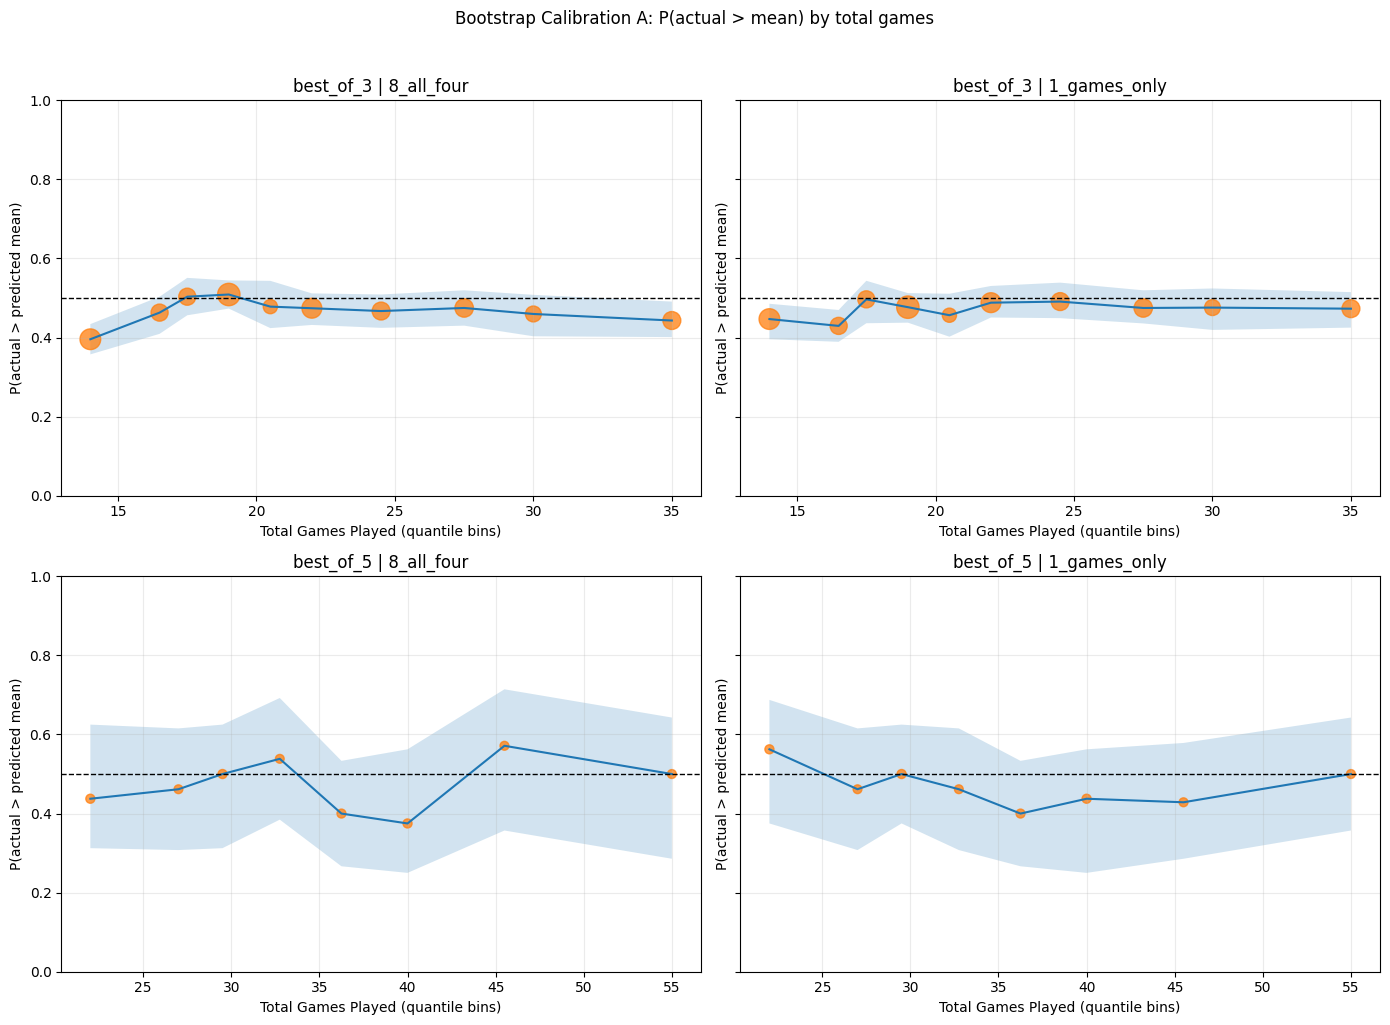

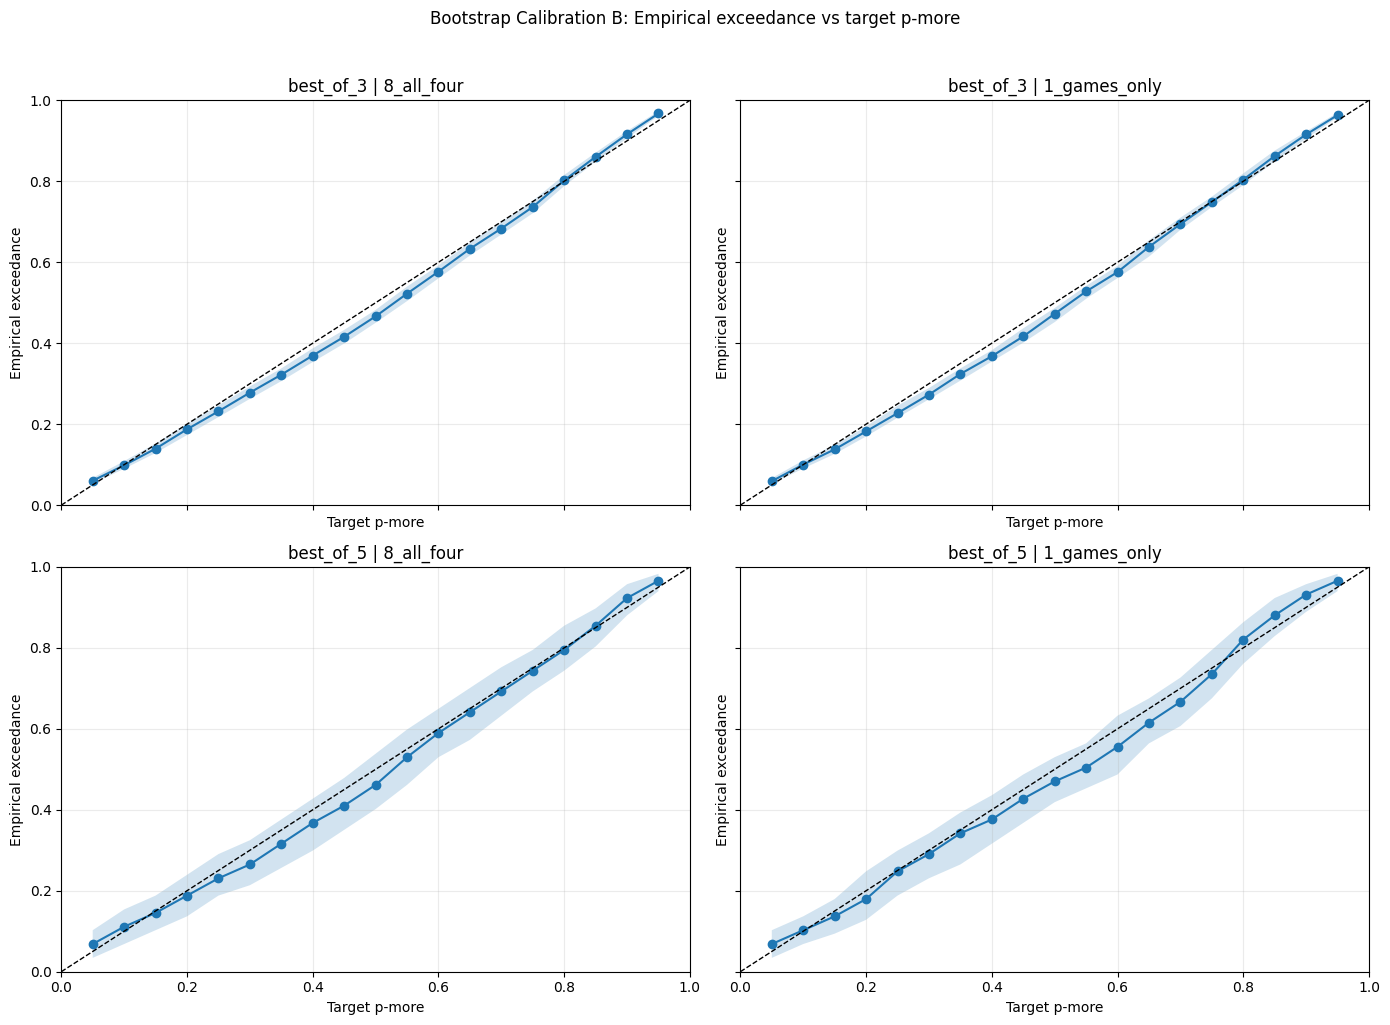

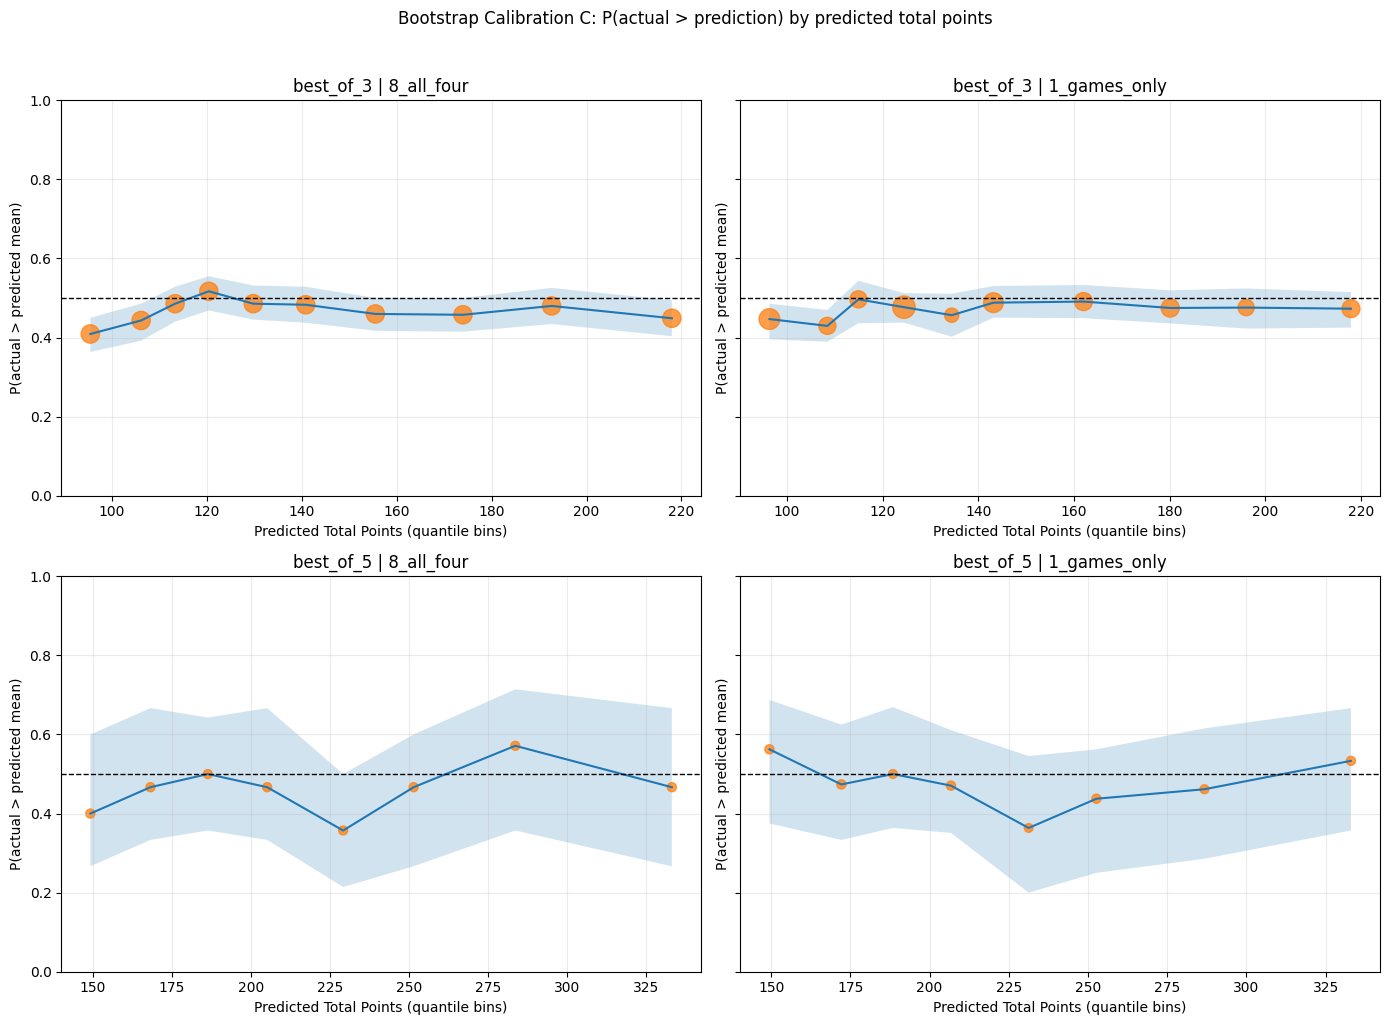

In [6]:
N_REPEATS = 500
TEST_SIZE = 0.30
P_MORE_GRID = np.arange(0.05, 1.00, 0.05)
normal = NormalDist(mu=0.0, sigma=1.0)

scenario_map = {
    "best": {
        "scenario": "8_all_four",
        "features": ["total_games_played", "total_aces_match", "break_rate", "total_tiebreaks_played"],
    },
    "worst": {
        "scenario": "1_games_only",
        "features": ["total_games_played"],
    },
}


def quantile_edges(series: pd.Series, n_bins: int) -> np.ndarray:
    vals = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    if len(vals) == 0:
        return np.array([0.0, 1.0])
    probs = np.linspace(0.0, 1.0, n_bins + 1)
    edges = np.unique(np.quantile(vals, probs))
    if len(edges) < 2:
        v = float(vals[0])
        edges = np.array([v - 0.5, v + 0.5])
    return edges


def summarize_curve(samples_2d: np.ndarray) -> dict:
    return {
        "p10": np.nanpercentile(samples_2d, 10, axis=0),
        "p50": np.nanpercentile(samples_2d, 50, axis=0),
        "p90": np.nanpercentile(samples_2d, 90, axis=0),
    }


def run_repeated_calibration(df_seg: pd.DataFrame, features: list[str], n_bins: int, n_repeats: int):
    data = df_seg.dropna(subset=features + ["total_points", "total_games_played"]).copy()
    X = data[features].to_numpy(dtype=float)
    y = data["total_points"].to_numpy(dtype=float)
    g = data["total_games_played"].to_numpy(dtype=float)

    edges = quantile_edges(data["total_games_played"], n_bins=n_bins)
    n_effective_bins = len(edges) - 1
    bin_mids = (edges[:-1] + edges[1:]) / 2.0

    # Fixed full-dataset bin IDs used for stratified train/test splitting.
    stratify_bins = pd.cut(data["total_games_played"], bins=edges, include_lowest=True, labels=False)
    if stratify_bins.isna().any():
        raise ValueError("Unable to assign one or more rows to a games bin for stratification.")
    stratify_bins = stratify_bins.astype(int)
    bin_counts = stratify_bins.value_counts(dropna=False)
    can_stratify = bin_counts.min() >= 2 and len(bin_counts) > 1

    curve1_samples, curve1_counts, curve2_samples = [], [], []
    curve3_x_samples, curve3_y_samples, curve3_count_samples = [], [], []

    for r in range(n_repeats):
        split_kwargs = {
            "test_size": TEST_SIZE,
            "random_state": 10000 + r,
        }
        if can_stratify:
            split_kwargs["stratify"] = stratify_bins

        X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(X, y, g, **split_kwargs)

        m = LinearRegression()
        m.fit(X_train, y_train)
        mu_train = m.predict(X_train)
        mu_test = m.predict(X_test)
        sigma = float(np.std(y_train - mu_train, ddof=1))
        sigma = max(sigma, 1e-6)

        test_df = pd.DataFrame({"games": g_test, "actual": y_test, "pred_mean": mu_test})
        test_df["is_above_mean"] = (test_df["actual"] > test_df["pred_mean"]).astype(float)
        test_df["bin_id"] = pd.cut(test_df["games"], bins=edges, include_lowest=True, labels=False)

        by_bin = test_df.groupby("bin_id", dropna=False)["is_above_mean"].agg(["mean", "size"]).rename(
            columns={"mean": "pct", "size": "n"}
        )

        curve_vals = np.full(n_effective_bins, np.nan)
        count_vals = np.zeros(n_effective_bins)
        for b in range(n_effective_bins):
            if b in by_bin.index and pd.notna(by_bin.loc[b, "pct"]):
                curve_vals[b] = float(by_bin.loc[b, "pct"])
                count_vals[b] = float(by_bin.loc[b, "n"])

        curve1_samples.append(curve_vals)
        curve1_counts.append(count_vals)

        # Calibration C: bin by predicted total points, then evaluate P(actual > pred_mean).
        pred_edges = quantile_edges(pd.Series(mu_test), n_bins=n_bins)
        pred_bins = pd.cut(mu_test, bins=pred_edges, include_lowest=True, labels=False)
        n_pred_bins = len(pred_edges) - 1
        pred_x_vals = np.full(n_pred_bins, np.nan)
        pred_y_vals = np.full(n_pred_bins, np.nan)
        pred_n_vals = np.zeros(n_pred_bins)
        pred_df = pd.DataFrame({"pred_mean": mu_test, "actual": y_test, "pred_bin_id": pred_bins})
        pred_df["is_above_pred"] = (pred_df["actual"] > pred_df["pred_mean"]).astype(float)
        pred_grouped = pred_df.groupby("pred_bin_id", dropna=False).agg(
            pred_mid=("pred_mean", "mean"),
            pct=("is_above_pred", "mean"),
            n=("is_above_pred", "size"),
        )
        for b in range(n_pred_bins):
            if b in pred_grouped.index and pd.notna(pred_grouped.loc[b, "pct"]):
                pred_x_vals[b] = float(pred_grouped.loc[b, "pred_mid"])
                pred_y_vals[b] = float(pred_grouped.loc[b, "pct"])
                pred_n_vals[b] = float(pred_grouped.loc[b, "n"])
        curve3_x_samples.append(pred_x_vals)
        curve3_y_samples.append(pred_y_vals)
        curve3_count_samples.append(pred_n_vals)

        exceed_vals = []
        for p_more in P_MORE_GRID:
            z = normal.inv_cdf(1.0 - p_more)
            threshold = mu_test + sigma * z
            exceed_vals.append(float((y_test > threshold).mean()))
        curve2_samples.append(np.array(exceed_vals, dtype=float))

    curve1_arr = np.vstack(curve1_samples)
    count_arr = np.vstack(curve1_counts)
    curve2_arr = np.vstack(curve2_samples)
    curve3_x_arr = np.vstack(curve3_x_samples)
    curve3_y_arr = np.vstack(curve3_y_samples)
    curve3_count_arr = np.vstack(curve3_count_samples)

    return {
        "bin_mids": bin_mids,
        "curve1": summarize_curve(curve1_arr),
        "curve1_mean_count": np.nanmean(count_arr, axis=0),
        "curve2": summarize_curve(curve2_arr),
        "curve3_x": np.nanmean(curve3_x_arr, axis=0),
        "curve3": summarize_curve(curve3_y_arr),
        "curve3_mean_count": np.nanmean(curve3_count_arr, axis=0),
    }


boot_payload = {}
for segment_label, bo in [("best_of_3", 3), ("best_of_5", 5)]:
    seg = df[df["summary_mode_best_of"] == bo].copy()
    n_bins = 10 if bo == 3 else 8
    for tier, cfg in scenario_map.items():
        boot_payload[(segment_label, tier)] = {
            "scenario": cfg["scenario"],
            "result": run_repeated_calibration(seg, cfg["features"], n_bins=n_bins, n_repeats=N_REPEATS),
        }

# Plot A
figA, axesA = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
figA.suptitle("Bootstrap Calibration A: P(actual > mean) by total games", y=1.02)

combined_counts = np.concatenate([
    np.asarray(payload["result"]["curve1_mean_count"], dtype=float)
    for payload in boot_payload.values()
])
valid_counts = combined_counts[np.isfinite(combined_counts)]
global_min_count = float(np.min(valid_counts)) if len(valid_counts) > 0 else np.nan
global_max_count = float(np.max(valid_counts)) if len(valid_counts) > 0 else np.nan

for idx, ((segment_label, tier), payload) in enumerate(boot_payload.items()):
    ax = axesA[idx // 2, idx % 2]
    res = payload["result"]
    x = res["bin_mids"]
    y10, y50, y90 = res["curve1"]["p10"], res["curve1"]["p50"], res["curve1"]["p90"]

    n_vals = np.asarray(res["curve1_mean_count"], dtype=float)
    if np.isfinite(global_min_count) and np.isfinite(global_max_count) and global_max_count > global_min_count:
        sizes = 40 + 220 * ((n_vals - global_min_count) / (global_max_count - global_min_count))
    else:
        sizes = np.full(len(x), 120.0)

    ax.fill_between(x, y10, y90, alpha=0.2)
    ax.plot(x, y50, linewidth=1.5)
    ax.scatter(x, y50, s=sizes, alpha=0.75)
    ax.axhline(0.5, linestyle="--", linewidth=1, color="black")

    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Total Games Played (quantile bins)")
    ax.set_ylabel("P(actual > predicted mean)")
    ax.set_title(f"{segment_label} | {payload['scenario']}")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Plot B
figB, axesB = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
figB.suptitle("Bootstrap Calibration B: Empirical exceedance vs target p-more", y=1.02)

for idx, ((segment_label, tier), payload) in enumerate(boot_payload.items()):
    ax = axesB[idx // 2, idx % 2]
    res = payload["result"]
    y10, y50, y90 = res["curve2"]["p10"], res["curve2"]["p50"], res["curve2"]["p90"]

    ax.fill_between(P_MORE_GRID, y10, y90, alpha=0.2)
    ax.plot(P_MORE_GRID, y50, marker="o", linewidth=1.5)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="black")

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Target p-more")
    ax.set_ylabel("Empirical exceedance")
    ax.set_title(f"{segment_label} | {payload['scenario']}")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Plot C
figC, axesC = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
figC.suptitle("Bootstrap Calibration C: P(actual > prediction) by predicted total points", y=1.02)

combined_counts_c = np.concatenate([
    np.asarray(payload["result"]["curve3_mean_count"], dtype=float)
    for payload in boot_payload.values()
])
valid_counts_c = combined_counts_c[np.isfinite(combined_counts_c)]
global_min_count_c = float(np.min(valid_counts_c)) if len(valid_counts_c) > 0 else np.nan
global_max_count_c = float(np.max(valid_counts_c)) if len(valid_counts_c) > 0 else np.nan

for idx, ((segment_label, tier), payload) in enumerate(boot_payload.items()):
    ax = axesC[idx // 2, idx % 2]
    res = payload["result"]
    x = np.asarray(res["curve3_x"], dtype=float)
    y10, y50, y90 = res["curve3"]["p10"], res["curve3"]["p50"], res["curve3"]["p90"]

    n_vals = np.asarray(res["curve3_mean_count"], dtype=float)
    if np.isfinite(global_min_count_c) and np.isfinite(global_max_count_c) and global_max_count_c > global_min_count_c:
        sizes = 40 + 220 * ((n_vals - global_min_count_c) / (global_max_count_c - global_min_count_c))
    else:
        sizes = np.full(len(x), 120.0)

    ax.fill_between(x, y10, y90, alpha=0.2)
    ax.plot(x, y50, linewidth=1.5)
    ax.scatter(x, y50, s=sizes, alpha=0.75)
    ax.axhline(0.5, linestyle="--", linewidth=1, color="black")

    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Predicted Total Points (quantile bins)")
    ax.set_ylabel("P(actual > predicted mean)")
    ax.set_title(f"{segment_label} | {payload['scenario']}")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Games-Only Calibration Plots

Calibration diagnostics for Gaussian models using only `total_games_played`, with repeated 70/30 bootstrap resampling.

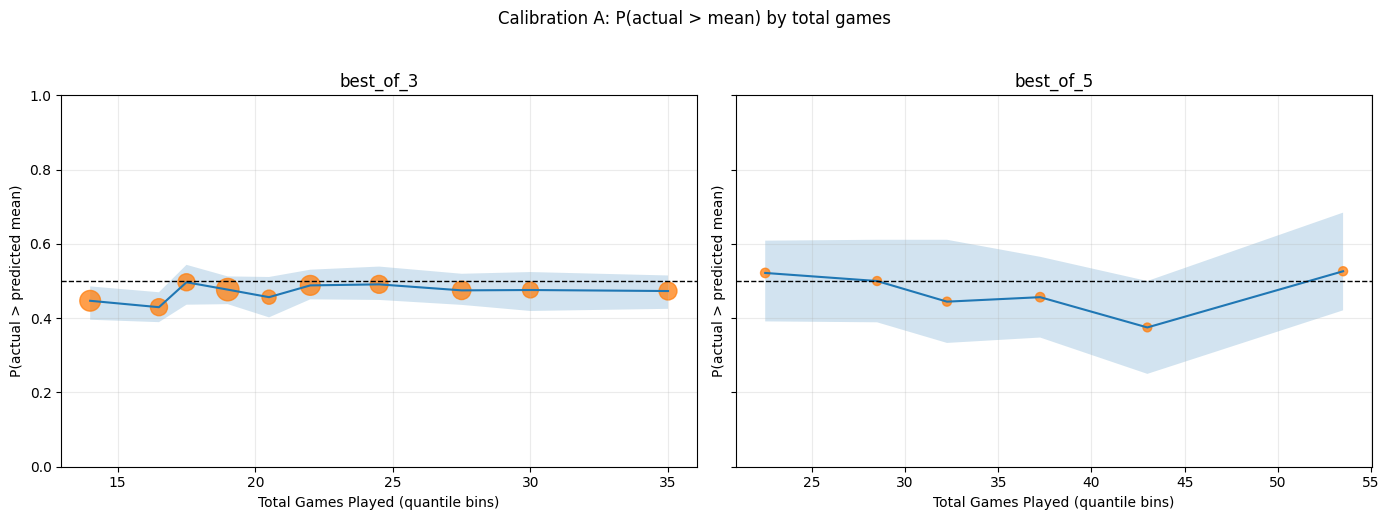

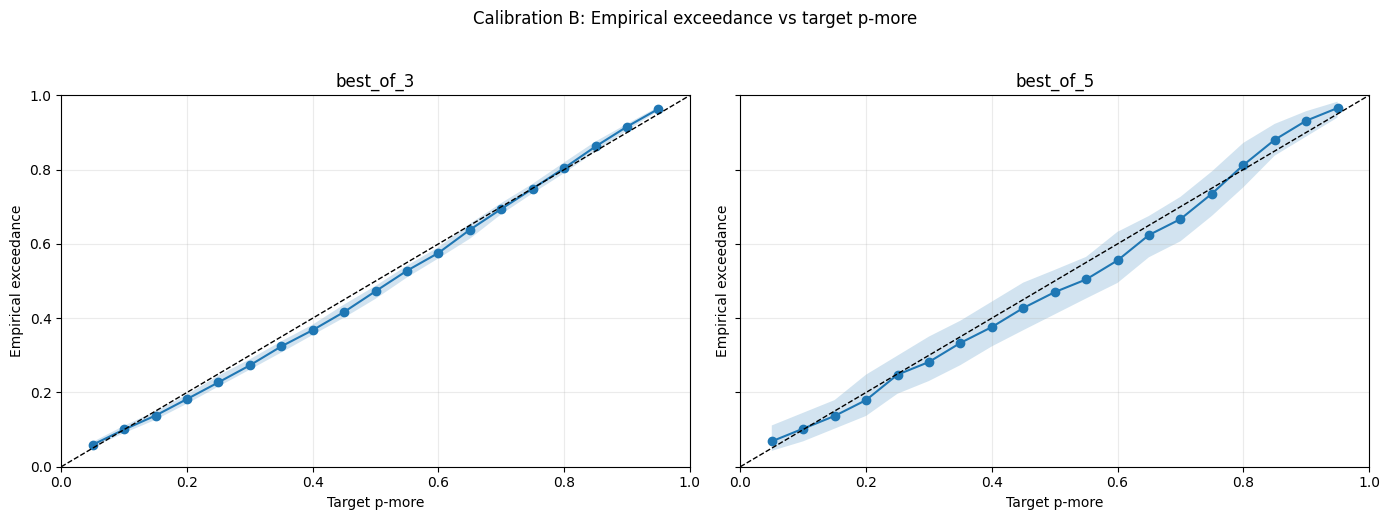

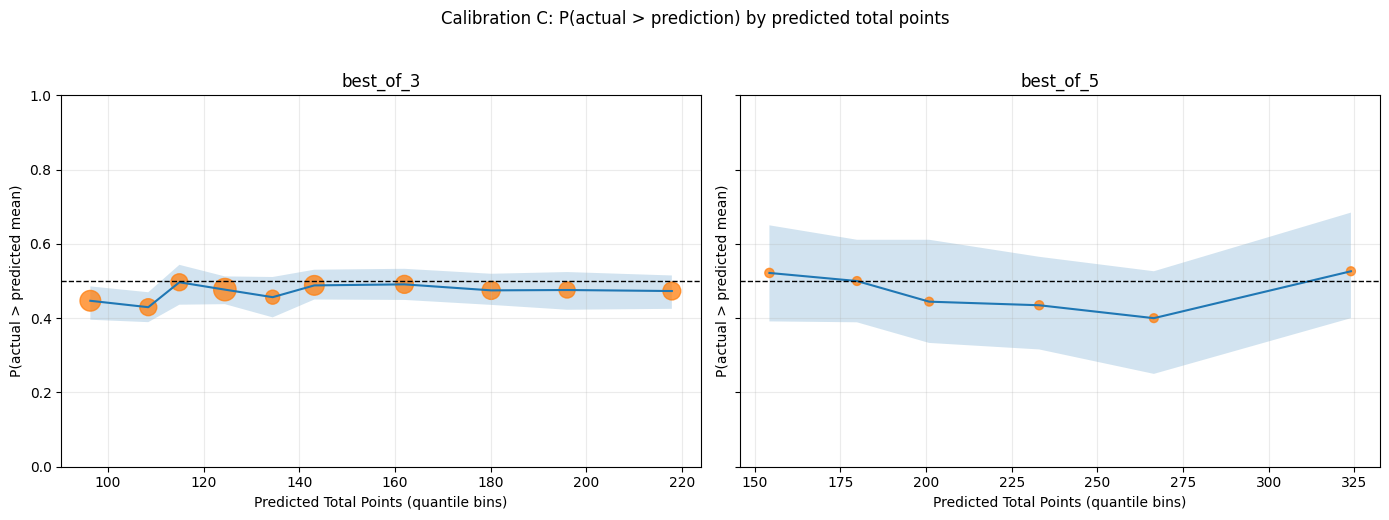

In [7]:
# Reuse run_repeated_calibration from the bootstrap section above.
# This section runs bo3 and bo5 for the games-only feature set.

if "run_repeated_calibration" not in globals():
    raise ValueError("run_repeated_calibration is not defined. Run the bootstrap calibration setup cell first.")

games_only_features = ["total_games_played"]

games_only_payload = {}
for segment_label, bo in [("best_of_3", 3), ("best_of_5", 5)]:
    seg = df[df["summary_mode_best_of"] == bo].copy()
    n_bins = 10 if bo == 3 else 6
    games_only_payload[segment_label] = run_repeated_calibration(
        df_seg=seg,
        features=games_only_features,
        n_bins=n_bins,
        n_repeats=N_REPEATS,
    )

# Plot A: P(actual > mean) by total-games bins
figA, axesA = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
figA.suptitle("Calibration A: P(actual > mean) by total games", y=1.03)

combined_counts = np.concatenate([
    np.asarray(games_only_payload[segment_label]["curve1_mean_count"], dtype=float)
    for segment_label in ["best_of_3", "best_of_5"]
])
valid_counts = combined_counts[np.isfinite(combined_counts)]
global_min_count = float(np.min(valid_counts)) if len(valid_counts) > 0 else np.nan
global_max_count = float(np.max(valid_counts)) if len(valid_counts) > 0 else np.nan

for i, segment_label in enumerate(["best_of_3", "best_of_5"]):
    ax = axesA[i]
    res = games_only_payload[segment_label]

    x = res["bin_mids"]
    y10, y50, y90 = res["curve1"]["p10"], res["curve1"]["p50"], res["curve1"]["p90"]

    n_vals = np.asarray(res["curve1_mean_count"], dtype=float)
    if np.isfinite(global_min_count) and np.isfinite(global_max_count) and global_max_count > global_min_count:
        sizes = 40 + 220 * ((n_vals - global_min_count) / (global_max_count - global_min_count))
    else:
        sizes = np.full(len(x), 120.0)

    ax.fill_between(x, y10, y90, alpha=0.2)
    ax.plot(x, y50, linewidth=1.5)
    ax.scatter(x, y50, s=sizes, alpha=0.75)
    ax.axhline(0.5, linestyle="--", linewidth=1, color="black")

    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Total Games Played (quantile bins)")
    ax.set_ylabel("P(actual > predicted mean)")
    ax.set_title(segment_label)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Plot B: p-more empirical exceedance
figB, axesB = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
figB.suptitle("Calibration B: Empirical exceedance vs target p-more", y=1.03)

for i, segment_label in enumerate(["best_of_3", "best_of_5"]):
    ax = axesB[i]
    res = games_only_payload[segment_label]

    y10, y50, y90 = res["curve2"]["p10"], res["curve2"]["p50"], res["curve2"]["p90"]

    ax.fill_between(P_MORE_GRID, y10, y90, alpha=0.2)
    ax.plot(P_MORE_GRID, y50, marker="o", linewidth=1.5)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="black")

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Target p-more")
    ax.set_ylabel("Empirical exceedance")
    ax.set_title(segment_label)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Plot C: P(actual > prediction) by predicted-total-points bins
figC, axesC = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
figC.suptitle("Calibration C: P(actual > prediction) by predicted total points", y=1.03)

combined_counts_c = np.concatenate([
    np.asarray(games_only_payload[segment_label]["curve3_mean_count"], dtype=float)
    for segment_label in ["best_of_3", "best_of_5"]
])
valid_counts_c = combined_counts_c[np.isfinite(combined_counts_c)]
global_min_count_c = float(np.min(valid_counts_c)) if len(valid_counts_c) > 0 else np.nan
global_max_count_c = float(np.max(valid_counts_c)) if len(valid_counts_c) > 0 else np.nan

for i, segment_label in enumerate(["best_of_3", "best_of_5"]):
    ax = axesC[i]
    res = games_only_payload[segment_label]

    x = np.asarray(res["curve3_x"], dtype=float)
    y10, y50, y90 = res["curve3"]["p10"], res["curve3"]["p50"], res["curve3"]["p90"]

    n_vals = np.asarray(res["curve3_mean_count"], dtype=float)
    if np.isfinite(global_min_count_c) and np.isfinite(global_max_count_c) and global_max_count_c > global_min_count_c:
        sizes = 40 + 220 * ((n_vals - global_min_count_c) / (global_max_count_c - global_min_count_c))
    else:
        sizes = np.full(len(x), 120.0)

    ax.fill_between(x, y10, y90, alpha=0.2)
    ax.plot(x, y50, linewidth=1.5)
    ax.scatter(x, y50, s=sizes, alpha=0.75)
    ax.axhline(0.5, linestyle="--", linewidth=1, color="black")

    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Predicted Total Points (quantile bins)")
    ax.set_ylabel("P(actual > predicted mean)")
    ax.set_title(segment_label)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Quantile Bin Diagnostics (10 Bins)

Print bin bounds and counts for `total_games_played` in bo3 and bo5.

In [8]:
def quantile_bin_table(df_seg: pd.DataFrame, n_bins: int = 10) -> pd.DataFrame:
    work = df_seg[["total_games_played"]].dropna().copy()
    work["total_games_played"] = pd.to_numeric(work["total_games_played"], errors="coerce")
    work = work.dropna(subset=["total_games_played"]).copy()

    # qcut may drop duplicate edges when games are discrete.
    work["game_bin"] = pd.qcut(work["total_games_played"], q=n_bins, duplicates="drop")

    out = (
        work.groupby("game_bin", observed=True)
        .agg(
            n=("total_games_played", "size"),
            min_games=("total_games_played", "min"),
            max_games=("total_games_played", "max"),
        )
        .reset_index()
    )
    out["bin_label"] = out["game_bin"].astype(str)
    return out[["bin_label", "min_games", "max_games", "n"]]

bo3_bins = quantile_bin_table(df[df["summary_mode_best_of"] == 3], n_bins=8)
bo5_bins = quantile_bin_table(df[df["summary_mode_best_of"] == 5], n_bins=8)

print("Best-of-3 (10 quantile bins):")
display(bo3_bins)

print("Best-of-5 (10 quantile bins):")
display(bo5_bins)

Best-of-3 (10 quantile bins):


,bin_label,min_games,max_games,n
0,"(11.999, 16.0]",12,16,782
1,"(16.0, 18.0]",17,18,992
2,"(18.0, 19.0]",19,19,501
3,"(19.0, 21.0]",20,21,743
4,"(21.0, 23.0]",22,23,708
5,"(23.0, 27.0]",24,27,739
6,"(27.0, 31.0]",28,31,830
7,"(31.0, 39.0]",32,39,556


Best-of-5 (10 quantile bins):


,bin_label,min_games,max_games,n
0,"(17.999, 26.0]",18,26,54
1,"(26.0, 28.0]",27,28,44
2,"(28.0, 31.0]",29,31,52
3,"(31.0, 34.5]",32,34,44
4,"(34.5, 38.0]",35,38,49
5,"(38.0, 42.0]",39,42,54
6,"(42.0, 49.0]",43,49,45
7,"(49.0, 61.0]",50,61,46


bo5 rows used: 388 | repeats: 500


,model,mae_mean,mae_std,rmse_mean,rmse_std,overall_exceed_mean,overall_exceed_bias_mean,weighted_bin_bias_mean
0,OLS,10.3623,0.6369,13.3075,0.7601,0.4716,0.0492,0.1094
1,RidgeCV,10.3619,0.6372,13.3081,0.7620,0.4708,0.0491,0.1096


Ridge selected alpha frequency:


,alpha,count
0,0.001000,112
1,0.001585,1
2,0.006310,1
3,0.025119,5
4,0.039811,7
5,0.063096,7
6,0.100000,27
7,0.158489,30
8,0.251189,48
9,0.398107,85


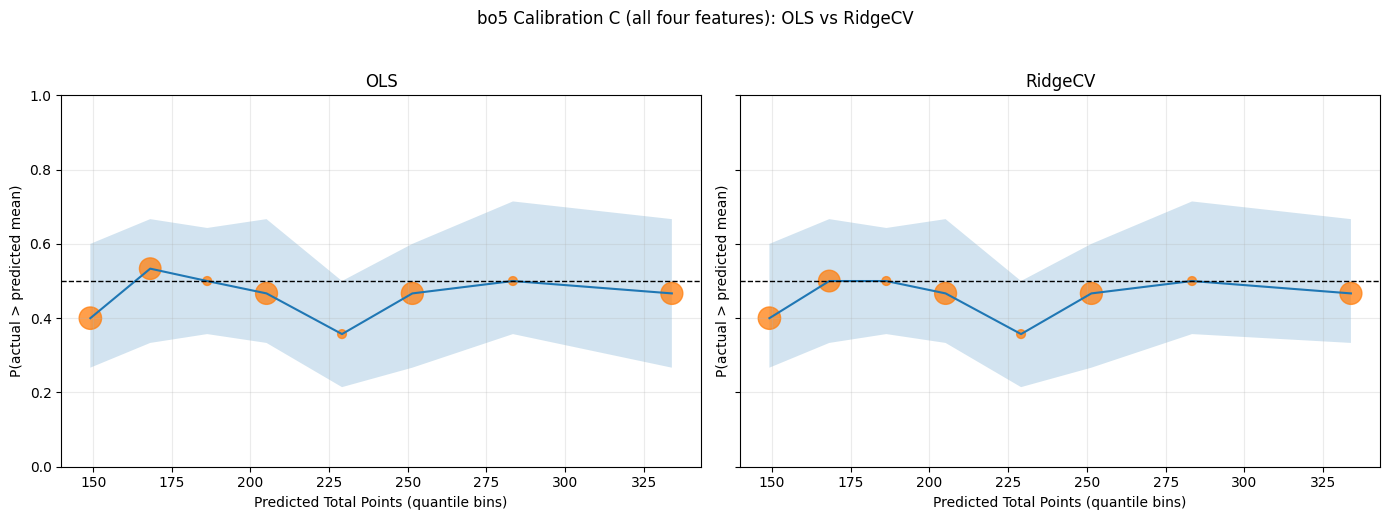

In [9]:
# bo5 all-four model tuning: OLS vs Ridge regularization
# Goal: improve calibration stability with limited bo5 sample size.

from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

if "quantile_edges" not in globals():
    raise ValueError("quantile_edges is not defined. Run the bootstrap calibration setup cells first.")

BO5_FEATURES = ["total_games_played", "total_aces_match", "break_rate", "total_tiebreaks_played"]
ALPHA_GRID = np.logspace(-3, 3, 31)
N_REPEATS_BO5 = N_REPEATS if "N_REPEATS" in globals() else 100
BO5_BINS = 8

bo5_data = (
    df[df["summary_mode_best_of"] == 5]
    .dropna(subset=BO5_FEATURES + ["total_points", "total_games_played"])
    .copy()
)

X = bo5_data[BO5_FEATURES].to_numpy(dtype=float)
y = bo5_data["total_points"].to_numpy(dtype=float)
g = bo5_data["total_games_played"].to_numpy(dtype=float)

# Keep the same stratification approach used in calibration sections.
game_edges = quantile_edges(bo5_data["total_games_played"], n_bins=BO5_BINS)
stratify_bins = pd.cut(bo5_data["total_games_played"], bins=game_edges, include_lowest=True, labels=False)
if stratify_bins.isna().any():
    raise ValueError("Unable to assign one or more bo5 rows to a games bin.")
stratify_bins = stratify_bins.astype(int)
can_stratify = stratify_bins.value_counts(dropna=False).min() >= 2 and stratify_bins.nunique() > 1


def build_ols():
    return LinearRegression()


def build_ridge():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHA_GRID, cv=5))


def collect_bo5_metrics(model_builder, model_name: str):
    rows = []
    curve_x_samples, curve_y_samples, curve_n_samples = [], [], []
    selected_alphas = []

    for r in range(N_REPEATS_BO5):
        split_kwargs = {"test_size": TEST_SIZE if "TEST_SIZE" in globals() else 0.3, "random_state": 20000 + r}
        if can_stratify:
            split_kwargs["stratify"] = stratify_bins

        X_train, X_test, y_train, y_test = train_test_split(X, y, **split_kwargs)

        model = model_builder()
        model.fit(X_train, y_train)

        mu_test = model.predict(X_test)
        resid_train = y_train - model.predict(X_train)
        sigma = max(float(np.std(resid_train, ddof=1)), 1e-6)

        mae = float(mean_absolute_error(y_test, mu_test))
        rmse = float(np.sqrt(mean_squared_error(y_test, mu_test)))
        overall_exceed = float((y_test > mu_test).mean())

        pred_edges = quantile_edges(pd.Series(mu_test), n_bins=BO5_BINS)
        pred_bins = pd.cut(mu_test, bins=pred_edges, include_lowest=True, labels=False)
        pred_df = pd.DataFrame({"pred": mu_test, "actual": y_test, "pred_bin": pred_bins})
        pred_df["above"] = (pred_df["actual"] > pred_df["pred"]).astype(float)
        grouped = pred_df.groupby("pred_bin", dropna=False).agg(
            pred_mid=("pred", "mean"),
            pct_above=("above", "mean"),
            n=("above", "size"),
        )

        n_bins_eff = len(pred_edges) - 1
        x_vals = np.full(n_bins_eff, np.nan)
        y_vals = np.full(n_bins_eff, np.nan)
        n_vals = np.zeros(n_bins_eff)
        for b in range(n_bins_eff):
            if b in grouped.index and pd.notna(grouped.loc[b, "pct_above"]):
                x_vals[b] = float(grouped.loc[b, "pred_mid"])
                y_vals[b] = float(grouped.loc[b, "pct_above"])
                n_vals[b] = float(grouped.loc[b, "n"])

        valid = np.isfinite(y_vals)
        if valid.any() and n_vals[valid].sum() > 0:
            weighted_bin_bias = float(np.average(np.abs(y_vals[valid] - 0.5), weights=n_vals[valid]))
        else:
            weighted_bin_bias = np.nan

        rows.append(
            {
                "model": model_name,
                "repeat": r,
                "mae": mae,
                "rmse": rmse,
                "overall_exceed": overall_exceed,
                "overall_exceed_bias": abs(overall_exceed - 0.5),
                "weighted_bin_bias": weighted_bin_bias,
                "sigma": sigma,
            }
        )

        if model_name == "RidgeCV":
            selected_alphas.append(float(model.named_steps["ridgecv"].alpha_))

        curve_x_samples.append(x_vals)
        curve_y_samples.append(y_vals)
        curve_n_samples.append(n_vals)

    metrics_df = pd.DataFrame(rows)
    curve_payload = {
        "x": np.nanmean(np.vstack(curve_x_samples), axis=0),
        "y": {
            "p10": np.nanpercentile(np.vstack(curve_y_samples), 10, axis=0),
            "p50": np.nanpercentile(np.vstack(curve_y_samples), 50, axis=0),
            "p90": np.nanpercentile(np.vstack(curve_y_samples), 90, axis=0),
        },
        "n_mean": np.nanmean(np.vstack(curve_n_samples), axis=0),
    }
    return metrics_df, curve_payload, selected_alphas


ols_metrics, ols_curve, _ = collect_bo5_metrics(build_ols, "OLS")
ridge_metrics, ridge_curve, ridge_alphas = collect_bo5_metrics(build_ridge, "RidgeCV")

compare = pd.concat([ols_metrics, ridge_metrics], ignore_index=True)
summary = (
    compare.groupby("model", as_index=False)
    .agg(
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        overall_exceed_mean=("overall_exceed", "mean"),
        overall_exceed_bias_mean=("overall_exceed_bias", "mean"),
        weighted_bin_bias_mean=("weighted_bin_bias", "mean"),
    )
    .sort_values(["weighted_bin_bias_mean", "mae_mean"])
)

print(f"bo5 rows used: {len(bo5_data)} | repeats: {N_REPEATS_BO5}")
display(summary.round(4))

if len(ridge_alphas) > 0:
    alpha_counts = pd.Series(ridge_alphas).value_counts().sort_index()
    print("Ridge selected alpha frequency:")
    display(alpha_counts.rename_axis("alpha").reset_index(name="count"))

# Shared size scaling across OLS vs Ridge for fair visual comparison.
combined_n = np.concatenate([
    np.asarray(ols_curve["n_mean"], dtype=float),
    np.asarray(ridge_curve["n_mean"], dtype=float),
])
valid_n = combined_n[np.isfinite(combined_n)]
min_n = float(np.min(valid_n)) if len(valid_n) > 0 else np.nan
max_n = float(np.max(valid_n)) if len(valid_n) > 0 else np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("bo5 Calibration C (all four features): OLS vs RidgeCV", y=1.03)

for ax, name, payload in [(axes[0], "OLS", ols_curve), (axes[1], "RidgeCV", ridge_curve)]:
    x = np.asarray(payload["x"], dtype=float)
    y10, y50, y90 = payload["y"]["p10"], payload["y"]["p50"], payload["y"]["p90"]
    n_vals = np.asarray(payload["n_mean"], dtype=float)

    if np.isfinite(min_n) and np.isfinite(max_n) and max_n > min_n:
        sizes = 40 + 220 * ((n_vals - min_n) / (max_n - min_n))
    else:
        sizes = np.full(len(x), 120.0)

    ax.fill_between(x, y10, y90, alpha=0.2)
    ax.plot(x, y50, linewidth=1.5)
    ax.scatter(x, y50, s=sizes, alpha=0.75)
    ax.axhline(0.5, linestyle="--", linewidth=1, color="black")
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Predicted Total Points (quantile bins)")
    ax.set_ylabel("P(actual > predicted mean)")
    ax.set_title(name)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


bo5 rows used: 388 | repeats: 500


,model,mae_mean,rmse_mean,calib_b_mae_mean,calib_c_bias_mean
1,Poisson,12.3830,16.0165,0.0328,0.1794
2,NegBin_NB2,12.3830,16.0165,0.0333,0.1794
0,Gaussian,10.3234,13.2393,0.0361,0.1087


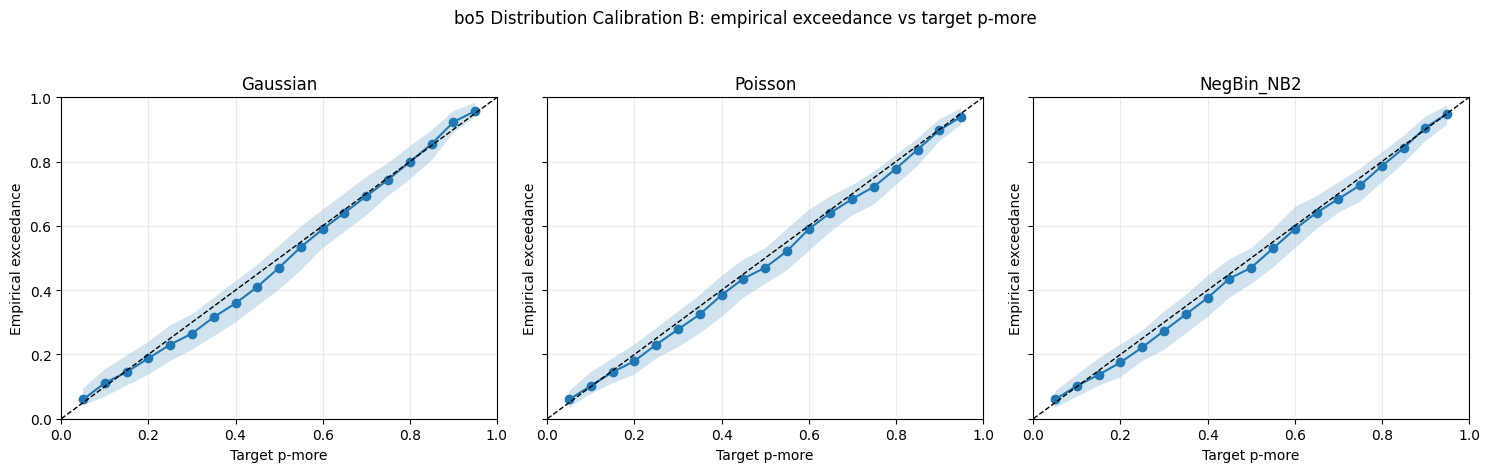

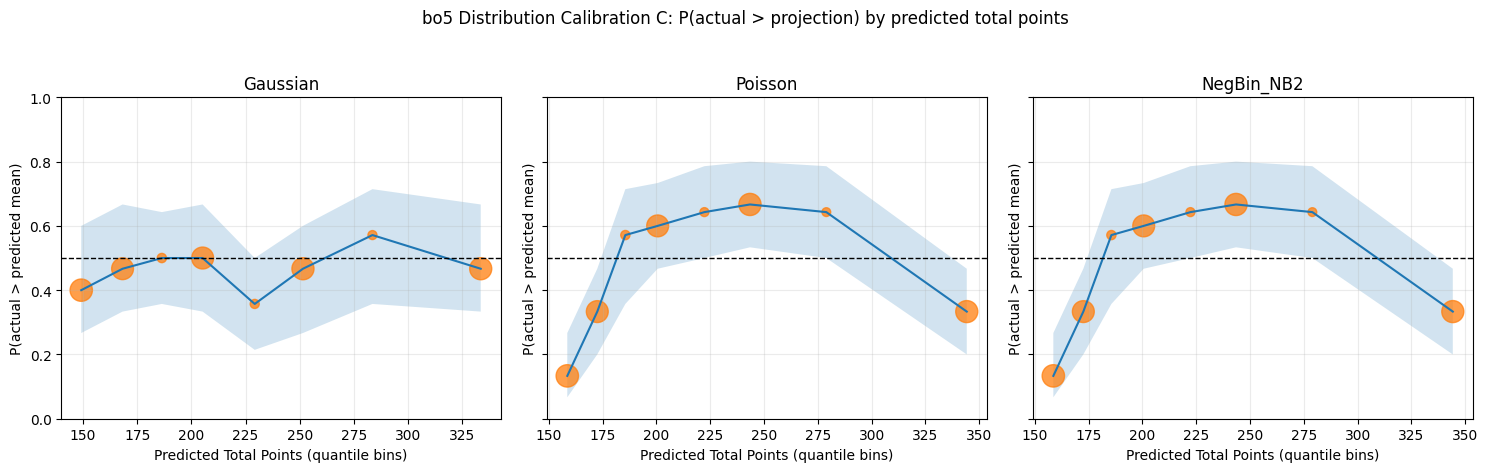

In [10]:
# bo5 distribution comparison for all-four features
# Compare calibration by distribution, not just MAE.

from scipy.stats import nbinom as sp_nbinom
from scipy.stats import poisson as sp_poisson
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

if "quantile_edges" not in globals() or "P_MORE_GRID" not in globals():
    raise ValueError("Run the bootstrap calibration setup cells first (quantile_edges, P_MORE_GRID required).")

BO5_FEATURES = ["total_games_played", "total_aces_match", "break_rate", "total_tiebreaks_played"]
BO5_BINS = 8
N_REPEATS_DIST = N_REPEATS if "N_REPEATS" in globals() else 100
TEST_SIZE_LOCAL = TEST_SIZE if "TEST_SIZE" in globals() else 0.3

bo5_data = (
    df[df["summary_mode_best_of"] == 5]
    .dropna(subset=BO5_FEATURES + ["total_points", "total_games_played"])
    .copy()
)

X = bo5_data[BO5_FEATURES].to_numpy(dtype=float)
y = bo5_data["total_points"].to_numpy(dtype=float)

# Same stratification logic as prior calibration work.
game_edges = quantile_edges(bo5_data["total_games_played"], n_bins=BO5_BINS)
stratify_bins = pd.cut(bo5_data["total_games_played"], bins=game_edges, include_lowest=True, labels=False)
if stratify_bins.isna().any():
    raise ValueError("Unable to assign one or more bo5 rows to a games bin.")
stratify_bins = stratify_bins.astype(int)
can_stratify = stratify_bins.value_counts(dropna=False).min() >= 2 and stratify_bins.nunique() > 1


def estimate_nb2_alpha(y_true: np.ndarray, mu: np.ndarray) -> float:
    """Method-of-moments NB2 dispersion estimate: Var(Y|X)=mu+alpha*mu^2."""
    mu_safe = np.clip(mu, 1e-6, None)
    raw = np.mean(((y_true - mu_safe) ** 2 - mu_safe) / (mu_safe**2))
    return float(max(raw, 1e-8))


def fit_and_predict_distribution(model_name: str, X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray):
    if model_name == "Gaussian":
        model = LinearRegression()
        model.fit(X_train, y_train)
        mu_train = model.predict(X_train)
        mu_test = model.predict(X_test)
        sigma = max(float(np.std(y_train - mu_train, ddof=1)), 1e-6)
        return mu_train, mu_test, {"sigma": sigma}

    if model_name == "Poisson":
        model = make_pipeline(StandardScaler(), PoissonRegressor(alpha=0.0, max_iter=2000))
        model.fit(X_train, y_train)
        mu_train = np.clip(model.predict(X_train), 1e-6, None)
        mu_test = np.clip(model.predict(X_test), 1e-6, None)
        return mu_train, mu_test, {}

    if model_name == "NegBin_NB2":
        # Mean from Poisson GLM, plus global NB2 dispersion estimated from train residuals.
        model = make_pipeline(StandardScaler(), PoissonRegressor(alpha=0.0, max_iter=2000))
        model.fit(X_train, y_train)
        mu_train = np.clip(model.predict(X_train), 1e-6, None)
        mu_test = np.clip(model.predict(X_test), 1e-6, None)
        alpha_nb2 = estimate_nb2_alpha(y_train, mu_train)
        return mu_train, mu_test, {"alpha_nb2": alpha_nb2}

    raise ValueError(f"Unknown model_name: {model_name}")


def threshold_for_p_more(model_name: str, mu: np.ndarray, params: dict, p_more: float) -> np.ndarray:
    # We want P(Y > threshold) ~= p_more.
    q = 1.0 - p_more

    if model_name == "Gaussian":
        z = normal.inv_cdf(q)
        return mu + params["sigma"] * z

    if model_name == "Poisson":
        return sp_poisson.ppf(q, mu)

    if model_name == "NegBin_NB2":
        alpha = max(float(params["alpha_nb2"]), 1e-8)
        r = 1.0 / alpha
        prob = r / (r + mu)
        return sp_nbinom.ppf(q, r, prob)

    raise ValueError(f"Unknown model_name: {model_name}")


model_names = ["Gaussian", "Poisson", "NegBin_NB2"]
results = {name: {"rows": [], "curve_b": [], "curve_c_x": [], "curve_c_y": [], "curve_c_n": []} for name in model_names}

for r in range(N_REPEATS_DIST):
    split_kwargs = {"test_size": TEST_SIZE_LOCAL, "random_state": 30000 + r}
    if can_stratify:
        split_kwargs["stratify"] = stratify_bins

    X_train, X_test, y_train, y_test = train_test_split(X, y, **split_kwargs)

    for name in model_names:
        mu_train, mu_test, params = fit_and_predict_distribution(name, X_train, y_train, X_test)

        # Point-prediction error (secondary).
        mae = float(mean_absolute_error(y_test, mu_test))
        rmse = float(np.sqrt(mean_squared_error(y_test, mu_test)))

        # Calibration B: empirical exceedance vs target p-more.
        exceed_vals = []
        for p_more in P_MORE_GRID:
            threshold = threshold_for_p_more(name, mu_test, params, float(p_more))
            exceed_vals.append(float((y_test > threshold).mean()))
        exceed_arr = np.array(exceed_vals, dtype=float)
        calib_b_mae = float(np.mean(np.abs(exceed_arr - P_MORE_GRID)))

        # Calibration C: bin by projected total points and check P(actual > projection).
        pred_edges = quantile_edges(pd.Series(mu_test), n_bins=BO5_BINS)
        pred_bins = pd.cut(mu_test, bins=pred_edges, include_lowest=True, labels=False)
        pred_df = pd.DataFrame({"pred": mu_test, "actual": y_test, "pred_bin": pred_bins})
        pred_df["above_pred"] = (pred_df["actual"] > pred_df["pred"]).astype(float)
        grouped = pred_df.groupby("pred_bin", dropna=False).agg(
            pred_mid=("pred", "mean"),
            pct_above=("above_pred", "mean"),
            n=("above_pred", "size"),
        )

        n_bins_eff = len(pred_edges) - 1
        x_vals = np.full(n_bins_eff, np.nan)
        y_vals = np.full(n_bins_eff, np.nan)
        n_vals = np.zeros(n_bins_eff)
        for b in range(n_bins_eff):
            if b in grouped.index and pd.notna(grouped.loc[b, "pct_above"]):
                x_vals[b] = float(grouped.loc[b, "pred_mid"])
                y_vals[b] = float(grouped.loc[b, "pct_above"])
                n_vals[b] = float(grouped.loc[b, "n"])

        valid = np.isfinite(y_vals)
        if valid.any() and n_vals[valid].sum() > 0:
            calib_c_bias = float(np.average(np.abs(y_vals[valid] - 0.5), weights=n_vals[valid]))
        else:
            calib_c_bias = np.nan

        results[name]["rows"].append(
            {
                "model": name,
                "repeat": r,
                "mae": mae,
                "rmse": rmse,
                "calib_b_mae": calib_b_mae,
                "calib_c_bias": calib_c_bias,
            }
        )
        results[name]["curve_b"].append(exceed_arr)
        results[name]["curve_c_x"].append(x_vals)
        results[name]["curve_c_y"].append(y_vals)
        results[name]["curve_c_n"].append(n_vals)

summary_rows = []
for name in model_names:
    mdf = pd.DataFrame(results[name]["rows"])
    summary_rows.append(
        {
            "model": name,
            "mae_mean": float(mdf["mae"].mean()),
            "rmse_mean": float(mdf["rmse"].mean()),
            "calib_b_mae_mean": float(mdf["calib_b_mae"].mean()),
            "calib_c_bias_mean": float(mdf["calib_c_bias"].mean()),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values(["calib_b_mae_mean", "calib_c_bias_mean", "mae_mean"])
print(f"bo5 rows used: {len(bo5_data)} | repeats: {N_REPEATS_DIST}")
display(summary_df.round(4))

# Plot B comparison across distributions.
figB, axesB = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 4.5), sharex=True, sharey=True)
figB.suptitle("bo5 Distribution Calibration B: empirical exceedance vs target p-more", y=1.04)

if len(model_names) == 1:
    axesB = [axesB]

for ax, name in zip(axesB, model_names):
    curve_b_arr = np.vstack(results[name]["curve_b"])
    y10 = np.nanpercentile(curve_b_arr, 10, axis=0)
    y50 = np.nanpercentile(curve_b_arr, 50, axis=0)
    y90 = np.nanpercentile(curve_b_arr, 90, axis=0)

    ax.fill_between(P_MORE_GRID, y10, y90, alpha=0.2)
    ax.plot(P_MORE_GRID, y50, marker="o", linewidth=1.5)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="black")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Target p-more")
    ax.set_ylabel("Empirical exceedance")
    ax.set_title(name)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Plot C comparison across distributions (shared marker-size scale).
combined_counts_c = np.concatenate([
    np.nanmean(np.vstack(results[name]["curve_c_n"]), axis=0)
    for name in model_names
])
valid_counts_c = combined_counts_c[np.isfinite(combined_counts_c)]
min_count_c = float(np.min(valid_counts_c)) if len(valid_counts_c) > 0 else np.nan
max_count_c = float(np.max(valid_counts_c)) if len(valid_counts_c) > 0 else np.nan

figC, axesC = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 4.5), sharey=True)
figC.suptitle("bo5 Distribution Calibration C: P(actual > projection) by predicted total points", y=1.04)

if len(model_names) == 1:
    axesC = [axesC]

for ax, name in zip(axesC, model_names):
    x = np.nanmean(np.vstack(results[name]["curve_c_x"]), axis=0)
    y_arr = np.vstack(results[name]["curve_c_y"])
    n_vals = np.nanmean(np.vstack(results[name]["curve_c_n"]), axis=0)

    y10 = np.nanpercentile(y_arr, 10, axis=0)
    y50 = np.nanpercentile(y_arr, 50, axis=0)
    y90 = np.nanpercentile(y_arr, 90, axis=0)

    if np.isfinite(min_count_c) and np.isfinite(max_count_c) and max_count_c > min_count_c:
        sizes = 40 + 220 * ((n_vals - min_count_c) / (max_count_c - min_count_c))
    else:
        sizes = np.full(len(x), 120.0)

    ax.fill_between(x, y10, y90, alpha=0.2)
    ax.plot(x, y50, linewidth=1.5)
    ax.scatter(x, y50, s=sizes, alpha=0.75)
    ax.axhline(0.5, linestyle="--", linewidth=1, color="black")
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Predicted Total Points (quantile bins)")
    ax.set_ylabel("P(actual > predicted mean)")
    ax.set_title(name)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


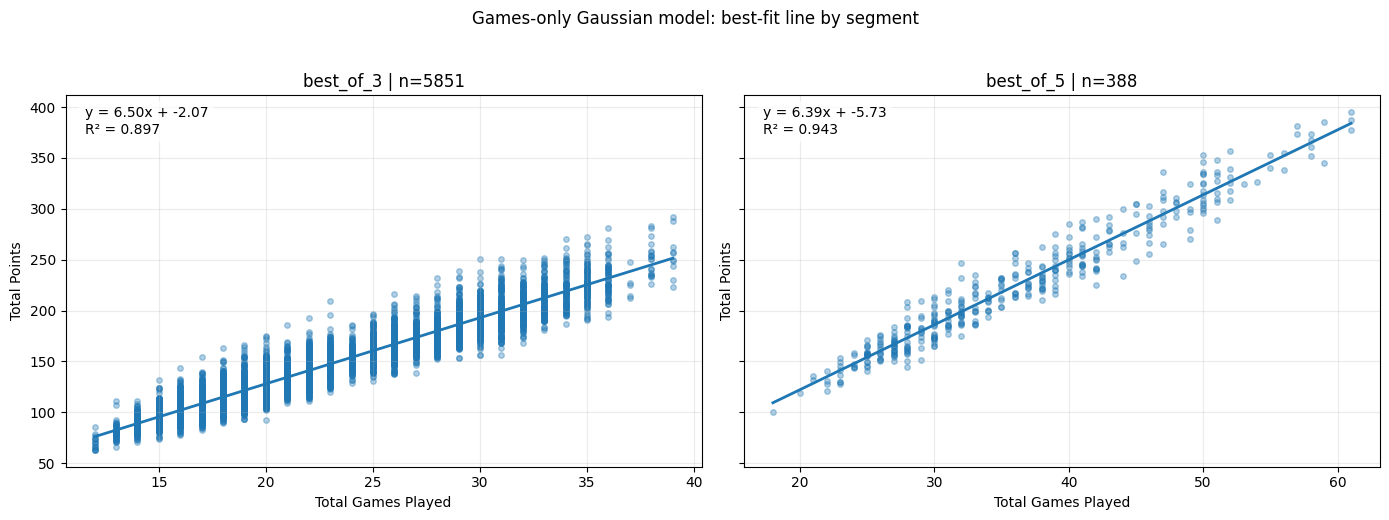

In [11]:
# Games-only model shape: scatter + best-fit line

from sklearn.metrics import r2_score

plot_df = (
    df[["summary_mode_best_of", "total_games_played", "total_points"]]
    .dropna()
    .copy()
)
plot_df["total_games_played"] = pd.to_numeric(plot_df["total_games_played"], errors="coerce")
plot_df["total_points"] = pd.to_numeric(plot_df["total_points"], errors="coerce")
plot_df = plot_df.dropna(subset=["total_games_played", "total_points"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Games-only Gaussian model: best-fit line by segment", y=1.03)

for ax, bo, label in [(axes[0], 3, "best_of_3"), (axes[1], 5, "best_of_5")]:
    seg = plot_df[plot_df["summary_mode_best_of"] == bo].copy()
    X = seg[["total_games_played"]].to_numpy(dtype=float)
    y = seg["total_points"].to_numpy(dtype=float)

    if len(seg) < 2:
        ax.set_title(f"{label} (insufficient rows)")
        ax.grid(alpha=0.25)
        continue

    m = LinearRegression()
    m.fit(X, y)
    y_hat = m.predict(X)

    x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    y_line = m.predict(x_line)

    ax.scatter(X[:, 0], y, s=16, alpha=0.35)
    ax.plot(x_line[:, 0], y_line, linewidth=2)

    slope = float(m.coef_[0])
    intercept = float(m.intercept_)
    r2 = float(r2_score(y, y_hat))

    ax.set_title(f"{label} | n={len(seg)}")
    ax.set_xlabel("Total Games Played")
    ax.set_ylabel("Total Points")
    ax.grid(alpha=0.25)
    ax.text(
        0.03,
        0.97,
        f"y = {slope:.2f}x + {intercept:.2f}\nR² = {r2:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
    )

plt.tight_layout()
plt.show()


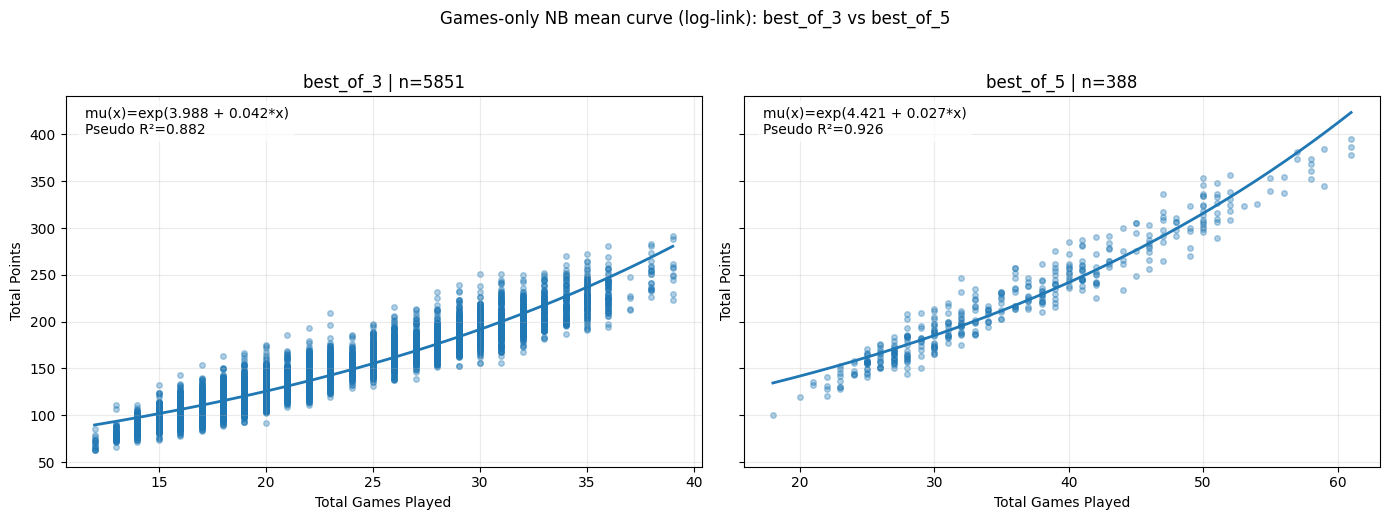

In [12]:
# Games-only Negative Binomial-style mean curve (log link)
# This visualizes the mean function shape for count-style regression.

from sklearn.linear_model import PoissonRegressor

nb_plot_df = (
    df[["summary_mode_best_of", "total_games_played", "total_points"]]
    .dropna()
    .copy()
)
nb_plot_df["total_games_played"] = pd.to_numeric(nb_plot_df["total_games_played"], errors="coerce")
nb_plot_df["total_points"] = pd.to_numeric(nb_plot_df["total_points"], errors="coerce")
nb_plot_df = nb_plot_df.dropna(subset=["total_games_played", "total_points"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Games-only NB mean curve (log-link): best_of_3 vs best_of_5", y=1.03)

for ax, bo, label in [(axes[0], 3, "best_of_3"), (axes[1], 5, "best_of_5")]:
    seg = nb_plot_df[nb_plot_df["summary_mode_best_of"] == bo].copy()
    X = seg[["total_games_played"]].to_numpy(dtype=float)
    y = seg["total_points"].to_numpy(dtype=float)

    if len(seg) < 2:
        ax.set_title(f"{label} (insufficient rows)")
        ax.grid(alpha=0.25)
        continue

    # Use Poisson log-link for the mean curve; this matches NB-style mean parameterization.
    # (NB adds dispersion on top of this mean.)
    mean_model = PoissonRegressor(alpha=0.0, max_iter=2000)
    mean_model.fit(X, y)

    x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    y_line = mean_model.predict(x_line)

    y_hat = mean_model.predict(X)

    ax.scatter(X[:, 0], y, s=16, alpha=0.35)
    ax.plot(x_line[:, 0], y_line, linewidth=2)

    beta0 = float(mean_model.intercept_)
    beta1 = float(mean_model.coef_[0])
    r2_like = float(r2_score(y, y_hat))

    ax.set_title(f"{label} | n={len(seg)}")
    ax.set_xlabel("Total Games Played")
    ax.set_ylabel("Total Points")
    ax.grid(alpha=0.25)
    ax.text(
        0.03,
        0.97,
        f"mu(x)=exp({beta0:.3f} + {beta1:.3f}*x)\nPseudo R²={r2_like:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
    )

plt.tight_layout()
plt.show()


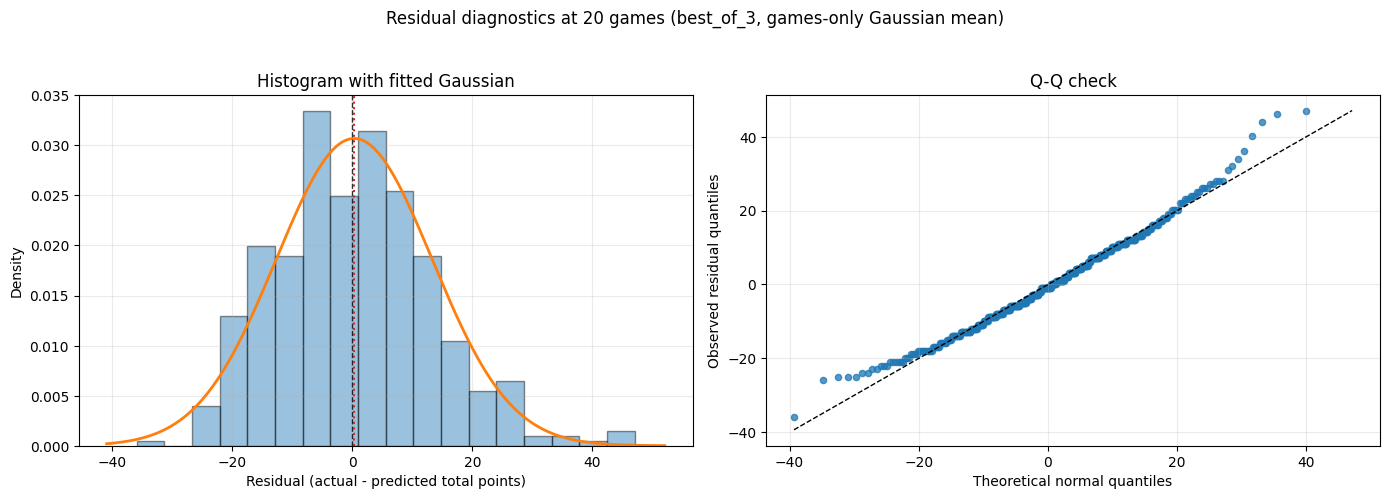

n=435 | predicted mean at 20 games ~= 127.93
residual mean=0.32, residual std=13.00


In [13]:
# Residual shape check at a fixed games line (games-only Gaussian model)

TARGET_GAMES = 20
TARGET_BO = 3  # focus on bo3 where 20-game matches are common

resid_df = (
    df[df["summary_mode_best_of"] == TARGET_BO][["total_games_played", "total_points"]]
    .dropna()
    .copy()
)
resid_df["total_games_played"] = pd.to_numeric(resid_df["total_games_played"], errors="coerce")
resid_df["total_points"] = pd.to_numeric(resid_df["total_points"], errors="coerce")
resid_df = resid_df.dropna(subset=["total_games_played", "total_points"]).copy()

X_all = resid_df[["total_games_played"]].to_numpy(dtype=float)
y_all = resid_df["total_points"].to_numpy(dtype=float)

g_model = LinearRegression()
g_model.fit(X_all, y_all)

slice_df = resid_df[resid_df["total_games_played"] == TARGET_GAMES].copy()

if len(slice_df) < 10:
    raise ValueError(
        f"Only {len(slice_df)} rows for best_of_{TARGET_BO} at {TARGET_GAMES} games; choose a games line with more samples."
    )

x_slice = slice_df[["total_games_played"]].to_numpy(dtype=float)
y_slice = slice_df["total_points"].to_numpy(dtype=float)
mu_slice = g_model.predict(x_slice)
residuals = y_slice - mu_slice

resid_mean = float(np.mean(residuals))
resid_std = float(np.std(residuals, ddof=1))

# Fitted Gaussian curve to compare against empirical residual histogram.
x_grid = np.linspace(residuals.min() - 5, residuals.max() + 5, 300)
gauss_pdf = (1.0 / (resid_std * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((x_grid - resid_mean) / resid_std) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
fig.suptitle(
    f"Residual diagnostics at {TARGET_GAMES} games (best_of_{TARGET_BO}, games-only Gaussian mean)",
    y=1.03,
)

# Histogram + fitted normal density
axes[0].hist(residuals, bins=18, density=True, alpha=0.45, edgecolor="black")
axes[0].plot(x_grid, gauss_pdf, linewidth=2)
axes[0].axvline(0.0, linestyle="--", linewidth=1, color="black", alpha=0.8)
axes[0].axvline(resid_mean, linestyle=":", linewidth=1.5, color="tab:red")
axes[0].set_xlabel("Residual (actual - predicted total points)")
axes[0].set_ylabel("Density")
axes[0].grid(alpha=0.25)
axes[0].set_title("Histogram with fitted Gaussian")

# Q-Q style plot vs normal quantiles
n = len(residuals)
p = (np.arange(1, n + 1) - 0.5) / n
theoretical = resid_mean + resid_std * np.array([normal.inv_cdf(pi) for pi in p])
observed = np.sort(residuals)
axes[1].scatter(theoretical, observed, s=20, alpha=0.75)
min_v = min(theoretical.min(), observed.min())
max_v = max(theoretical.max(), observed.max())
axes[1].plot([min_v, max_v], [min_v, max_v], linestyle="--", linewidth=1, color="black")
axes[1].set_xlabel("Theoretical normal quantiles")
axes[1].set_ylabel("Observed residual quantiles")
axes[1].grid(alpha=0.25)
axes[1].set_title("Q-Q check")

plt.tight_layout()
plt.show()

print(f"n={len(residuals)} | predicted mean at {TARGET_GAMES} games ~= {float(mu_slice.mean()):.2f}")
print(f"residual mean={resid_mean:.2f}, residual std={resid_std:.2f}")


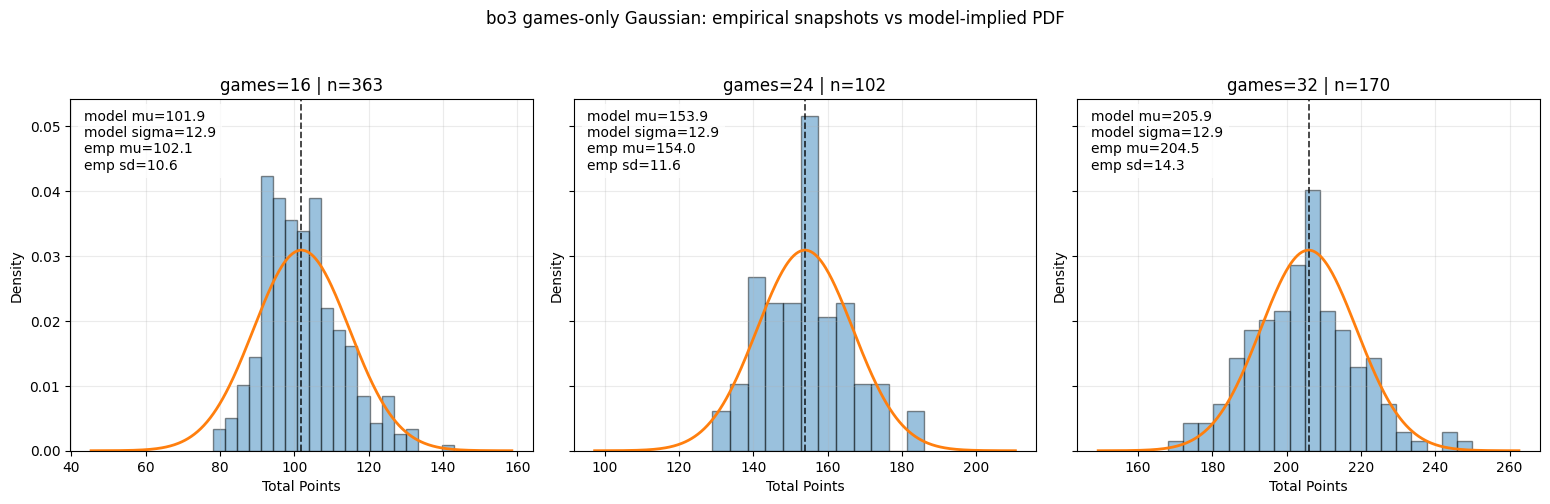

Global bo3 sigma from games-only Gaussian residuals: 12.901


In [14]:
# Model-implied Gaussian PDF check at fixed games lines (bo3)
# Uses global sigma from games-only Gaussian residuals (not slice-fitted sigma).

GAMES_LINES = [16, 24, 32]
TARGET_BO = 3

pdf_df = (
    df[df["summary_mode_best_of"] == TARGET_BO][["total_games_played", "total_points"]]
    .dropna()
    .copy()
)
pdf_df["total_games_played"] = pd.to_numeric(pdf_df["total_games_played"], errors="coerce")
pdf_df["total_points"] = pd.to_numeric(pdf_df["total_points"], errors="coerce")
pdf_df = pdf_df.dropna(subset=["total_games_played", "total_points"]).copy()

X_all = pdf_df[["total_games_played"]].to_numpy(dtype=float)
y_all = pdf_df["total_points"].to_numpy(dtype=float)

gauss_games_model = LinearRegression()
gauss_games_model.fit(X_all, y_all)
mu_all = gauss_games_model.predict(X_all)
# This matches the modeling assumption: one global sigma for the segment.
sigma_global = max(float(np.std(y_all - mu_all, ddof=1)), 1e-6)

fig, axes = plt.subplots(1, len(GAMES_LINES), figsize=(5.2 * len(GAMES_LINES), 4.8), sharey=True)
fig.suptitle(
    "bo3 games-only Gaussian: empirical snapshots vs model-implied PDF",
    y=1.04,
)

if len(GAMES_LINES) == 1:
    axes = [axes]

for ax, g in zip(axes, GAMES_LINES):
    snap = pdf_df[pdf_df["total_games_played"] == g]["total_points"].to_numpy(dtype=float)
    n = len(snap)

    if n < 5:
        ax.set_title(f"games={g} | n={n} (too few)")
        ax.grid(alpha=0.25)
        continue

    mu_g = float(gauss_games_model.predict(np.array([[float(g)]]))[0])

    x_min = min(float(np.min(snap)), mu_g - 4.0 * sigma_global)
    x_max = max(float(np.max(snap)), mu_g + 4.0 * sigma_global)
    x_grid = np.linspace(x_min - 5, x_max + 5, 400)

    model_pdf = (1.0 / (sigma_global * np.sqrt(2.0 * np.pi))) * np.exp(
        -0.5 * ((x_grid - mu_g) / sigma_global) ** 2
    )

    ax.hist(snap, bins=min(20, max(8, n // 8)), density=True, alpha=0.45, edgecolor="black")
    ax.plot(x_grid, model_pdf, linewidth=2)
    ax.axvline(mu_g, linestyle="--", linewidth=1.25, color="black", alpha=0.8)

    emp_mean = float(np.mean(snap))
    emp_std = float(np.std(snap, ddof=1)) if n > 1 else np.nan

    ax.set_title(f"games={g} | n={n}")
    ax.set_xlabel("Total Points")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.25)
    ax.text(
        0.03,
        0.97,
        f"model mu={mu_g:.1f}\nmodel sigma={sigma_global:.1f}\nemp mu={emp_mean:.1f}\nemp sd={emp_std:.1f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"facecolor": "white", "alpha": 0.78, "edgecolor": "none"},
    )

plt.tight_layout()
plt.show()

print(f"Global bo3 sigma from games-only Gaussian residuals: {sigma_global:.3f}")


Heteroskedastic Gaussian MLE summary | repeats=500


,segment,mae_mean,rmse_mean,calib_b_mae_mean,calib_c_bias_mean,avg_sigma_test_mean,var_games_coef_mean
0,best_of_3,9.5779,12.2002,0.0188,0.0448,12.0854,0.2527
1,best_of_5,10.3079,13.2228,0.0357,0.1091,12.9538,0.2738


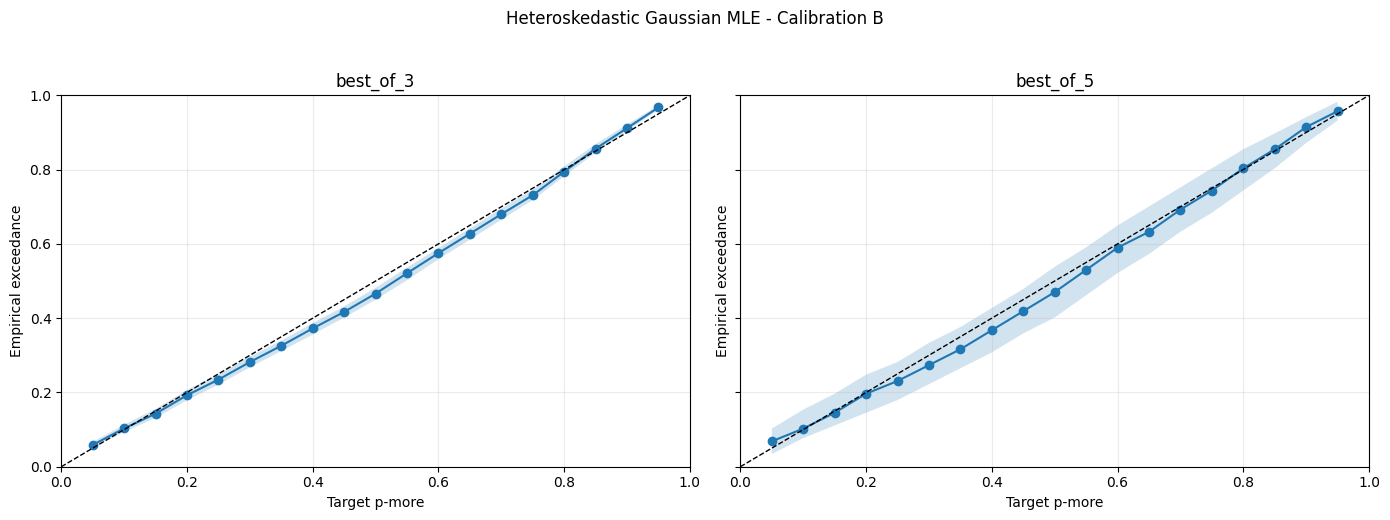

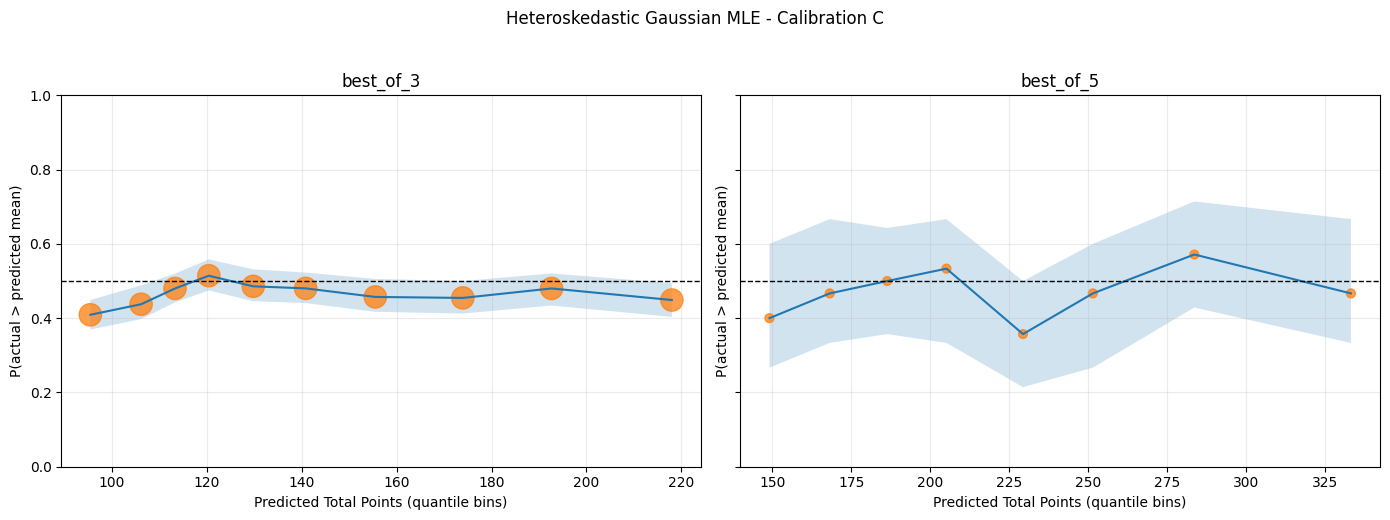

In [15]:
# Heteroskedastic Gaussian MLE
# Model 1 (mean): Gaussian MLE on all four features
# Model 2 (variance): Gaussian MLE on residual variance using only total_games_played

from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler

if "quantile_edges" not in globals() or "P_MORE_GRID" not in globals():
    raise ValueError("Run the calibration setup cells first (quantile_edges and P_MORE_GRID are required).")

MLE_FEATURES = ["total_games_played", "total_aces_match", "break_rate", "total_tiebreaks_played"]
N_REPEATS_MLE = N_REPEATS if "N_REPEATS" in globals() else 100
TEST_SIZE_MLE = TEST_SIZE if "TEST_SIZE" in globals() else 0.3


def fit_gaussian_mean_mle(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Fit Gaussian mean model via MLE with homoskedastic sigma nuisance param."""
    n = X.shape[0]
    Xd = np.column_stack([np.ones(n), X])

    beta_init = np.linalg.lstsq(Xd, y, rcond=None)[0]
    resid_init = y - Xd @ beta_init
    sigma_init = max(float(np.std(resid_init, ddof=1)), 1e-3)
    theta0 = np.concatenate([beta_init, np.array([np.log(sigma_init)])])

    def nll(theta: np.ndarray) -> float:
        beta = theta[:-1]
        log_sigma = theta[-1]
        sigma2 = np.exp(2.0 * log_sigma)
        resid = y - Xd @ beta
        return float(0.5 * np.sum(np.log(2.0 * np.pi * sigma2) + (resid**2) / sigma2))

    res = minimize(nll, theta0, method="L-BFGS-B")
    theta_hat = res.x if res.success else theta0
    return theta_hat[:-1]


def predict_mean(X: np.ndarray, beta: np.ndarray) -> np.ndarray:
    Xd = np.column_stack([np.ones(X.shape[0]), X])
    return Xd @ beta


def fit_variance_mle_from_residuals(games: np.ndarray, residuals: np.ndarray) -> tuple[np.ndarray, float, float]:
    """
    Fit log-variance model via MLE:
      log(sigma^2) = gamma0 + gamma1 * scaled_games
    using residuals from mean model.
    """
    g = games.astype(float)
    g_mean = float(np.mean(g))
    g_std = float(np.std(g, ddof=0))
    if g_std <= 0:
        g_std = 1.0
    g_scaled = (g - g_mean) / g_std

    Z = np.column_stack([np.ones(len(g_scaled)), g_scaled])
    eps = 1e-6
    gamma_init = np.linalg.lstsq(Z, np.log(residuals**2 + eps), rcond=None)[0]

    def nll(gamma: np.ndarray) -> float:
        log_var = Z @ gamma
        var = np.exp(log_var)
        return float(0.5 * np.sum(np.log(2.0 * np.pi * var) + (residuals**2) / var))

    res = minimize(nll, gamma_init, method="L-BFGS-B")
    gamma_hat = res.x if res.success else gamma_init
    return gamma_hat, g_mean, g_std


def predict_sigma(games: np.ndarray, gamma: np.ndarray, g_mean: float, g_std: float) -> np.ndarray:
    g_scaled = (games.astype(float) - g_mean) / g_std
    log_var = gamma[0] + gamma[1] * g_scaled
    sigma = np.sqrt(np.exp(log_var))
    return np.clip(sigma, 1e-6, None)


def run_segment_mle_calibration(df_seg: pd.DataFrame, n_bins: int, n_repeats: int) -> dict:
    data = df_seg.dropna(subset=MLE_FEATURES + ["total_points", "total_games_played"]).copy()
    X_raw = data[MLE_FEATURES].to_numpy(dtype=float)
    y = data["total_points"].to_numpy(dtype=float)
    games = data["total_games_played"].to_numpy(dtype=float)

    edges = quantile_edges(data["total_games_played"], n_bins=n_bins)
    stratify_bins = pd.cut(data["total_games_played"], bins=edges, include_lowest=True, labels=False)
    if stratify_bins.isna().any():
        raise ValueError("Unable to assign one or more rows to a games bin for stratification.")
    stratify_bins = stratify_bins.astype(int)
    can_stratify = stratify_bins.value_counts(dropna=False).min() >= 2 and stratify_bins.nunique() > 1

    curve_b_samples = []
    curve_c_x_samples, curve_c_y_samples, curve_c_n_samples = [], [], []
    rows = []

    for r in range(n_repeats):
        split_kwargs = {"test_size": TEST_SIZE_MLE, "random_state": 40000 + r}
        if can_stratify:
            split_kwargs["stratify"] = stratify_bins

        X_train_raw, X_test_raw, y_train, y_test, g_train, g_test = train_test_split(
            X_raw, y, games, **split_kwargs
        )

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        beta_hat = fit_gaussian_mean_mle(X_train, y_train)
        mu_train = predict_mean(X_train, beta_hat)
        mu_test = predict_mean(X_test, beta_hat)

        resid_train = y_train - mu_train
        gamma_hat, g_mean, g_std = fit_variance_mle_from_residuals(g_train, resid_train)
        sigma_test = predict_sigma(g_test, gamma_hat, g_mean, g_std)

        mae = float(mean_absolute_error(y_test, mu_test))
        rmse = float(np.sqrt(mean_squared_error(y_test, mu_test)))

        # Calibration B: empirical exceedance vs target p-more.
        exceed_vals = []
        for p_more in P_MORE_GRID:
            z = normal.inv_cdf(1.0 - float(p_more))
            threshold = mu_test + sigma_test * z
            exceed_vals.append(float((y_test > threshold).mean()))
        exceed_arr = np.array(exceed_vals, dtype=float)

        # Calibration C: P(actual > mean) by predicted-total-points bins.
        pred_edges = quantile_edges(pd.Series(mu_test), n_bins=n_bins)
        pred_bins = pd.cut(mu_test, bins=pred_edges, include_lowest=True, labels=False)
        pred_df = pd.DataFrame({"pred": mu_test, "actual": y_test, "pred_bin": pred_bins})
        pred_df["above_pred"] = (pred_df["actual"] > pred_df["pred"]).astype(float)
        grouped = pred_df.groupby("pred_bin", dropna=False).agg(
            pred_mid=("pred", "mean"),
            pct_above=("above_pred", "mean"),
            n=("above_pred", "size"),
        )

        n_eff = len(pred_edges) - 1
        x_vals = np.full(n_eff, np.nan)
        y_vals = np.full(n_eff, np.nan)
        n_vals = np.zeros(n_eff)
        for b in range(n_eff):
            if b in grouped.index and pd.notna(grouped.loc[b, "pct_above"]):
                x_vals[b] = float(grouped.loc[b, "pred_mid"])
                y_vals[b] = float(grouped.loc[b, "pct_above"])
                n_vals[b] = float(grouped.loc[b, "n"])

        valid = np.isfinite(y_vals)
        calib_c_bias = (
            float(np.average(np.abs(y_vals[valid] - 0.5), weights=n_vals[valid]))
            if valid.any() and n_vals[valid].sum() > 0
            else np.nan
        )

        rows.append(
            {
                "repeat": r,
                "mae": mae,
                "rmse": rmse,
                "calib_b_mae": float(np.mean(np.abs(exceed_arr - P_MORE_GRID))),
                "calib_c_bias": calib_c_bias,
                "avg_sigma_test": float(np.mean(sigma_test)),
                "var_games_coef": float(gamma_hat[1]),
            }
        )

        curve_b_samples.append(exceed_arr)
        curve_c_x_samples.append(x_vals)
        curve_c_y_samples.append(y_vals)
        curve_c_n_samples.append(n_vals)

    metrics_df = pd.DataFrame(rows)
    return {
        "metrics": metrics_df,
        "curve_b": {
            "p10": np.nanpercentile(np.vstack(curve_b_samples), 10, axis=0),
            "p50": np.nanpercentile(np.vstack(curve_b_samples), 50, axis=0),
            "p90": np.nanpercentile(np.vstack(curve_b_samples), 90, axis=0),
        },
        "curve_c_x": np.nanmean(np.vstack(curve_c_x_samples), axis=0),
        "curve_c": {
            "p10": np.nanpercentile(np.vstack(curve_c_y_samples), 10, axis=0),
            "p50": np.nanpercentile(np.vstack(curve_c_y_samples), 50, axis=0),
            "p90": np.nanpercentile(np.vstack(curve_c_y_samples), 90, axis=0),
        },
        "curve_c_mean_count": np.nanmean(np.vstack(curve_c_n_samples), axis=0),
    }


mle_payload = {}
for segment_label, bo in [("best_of_3", 3), ("best_of_5", 5)]:
    seg = df[df["summary_mode_best_of"] == bo].copy()
    n_bins = 10 if bo == 3 else 8
    mle_payload[segment_label] = run_segment_mle_calibration(seg, n_bins=n_bins, n_repeats=N_REPEATS_MLE)

summary_rows = []
for segment_label, payload in mle_payload.items():
    mdf = payload["metrics"]
    summary_rows.append(
        {
            "segment": segment_label,
            "mae_mean": float(mdf["mae"].mean()),
            "rmse_mean": float(mdf["rmse"].mean()),
            "calib_b_mae_mean": float(mdf["calib_b_mae"].mean()),
            "calib_c_bias_mean": float(mdf["calib_c_bias"].mean()),
            "avg_sigma_test_mean": float(mdf["avg_sigma_test"].mean()),
            "var_games_coef_mean": float(mdf["var_games_coef"].mean()),
        }
    )

mle_summary = pd.DataFrame(summary_rows).sort_values("segment")
print(f"Heteroskedastic Gaussian MLE summary | repeats={N_REPEATS_MLE}")
display(mle_summary.round(4))

# Plot B for new approach
figB, axesB = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
figB.suptitle("Heteroskedastic Gaussian MLE - Calibration B", y=1.03)

for i, segment_label in enumerate(["best_of_3", "best_of_5"]):
    ax = axesB[i]
    res = mle_payload[segment_label]
    y10, y50, y90 = res["curve_b"]["p10"], res["curve_b"]["p50"], res["curve_b"]["p90"]

    ax.fill_between(P_MORE_GRID, y10, y90, alpha=0.2)
    ax.plot(P_MORE_GRID, y50, marker="o", linewidth=1.5)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="black")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Target p-more")
    ax.set_ylabel("Empirical exceedance")
    ax.set_title(segment_label)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Plot C for new approach (shared marker-size scale).
combined_counts_c = np.concatenate([
    np.asarray(mle_payload[segment]["curve_c_mean_count"], dtype=float)
    for segment in ["best_of_3", "best_of_5"]
])
valid_counts_c = combined_counts_c[np.isfinite(combined_counts_c)]
min_count_c = float(np.min(valid_counts_c)) if len(valid_counts_c) > 0 else np.nan
max_count_c = float(np.max(valid_counts_c)) if len(valid_counts_c) > 0 else np.nan

figC, axesC = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
figC.suptitle("Heteroskedastic Gaussian MLE - Calibration C", y=1.03)

for i, segment_label in enumerate(["best_of_3", "best_of_5"]):
    ax = axesC[i]
    res = mle_payload[segment_label]
    x = np.asarray(res["curve_c_x"], dtype=float)
    y10, y50, y90 = res["curve_c"]["p10"], res["curve_c"]["p50"], res["curve_c"]["p90"]
    n_vals = np.asarray(res["curve_c_mean_count"], dtype=float)

    if np.isfinite(min_count_c) and np.isfinite(max_count_c) and max_count_c > min_count_c:
        sizes = 40 + 220 * ((n_vals - min_count_c) / (max_count_c - min_count_c))
    else:
        sizes = np.full(len(x), 120.0)

    ax.fill_between(x, y10, y90, alpha=0.2)
    ax.plot(x, y50, linewidth=1.5)
    ax.scatter(x, y50, s=sizes, alpha=0.75)
    ax.axhline(0.5, linestyle="--", linewidth=1, color="black")
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Predicted Total Points (quantile bins)")
    ax.set_ylabel("P(actual > predicted mean)")
    ax.set_title(segment_label)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


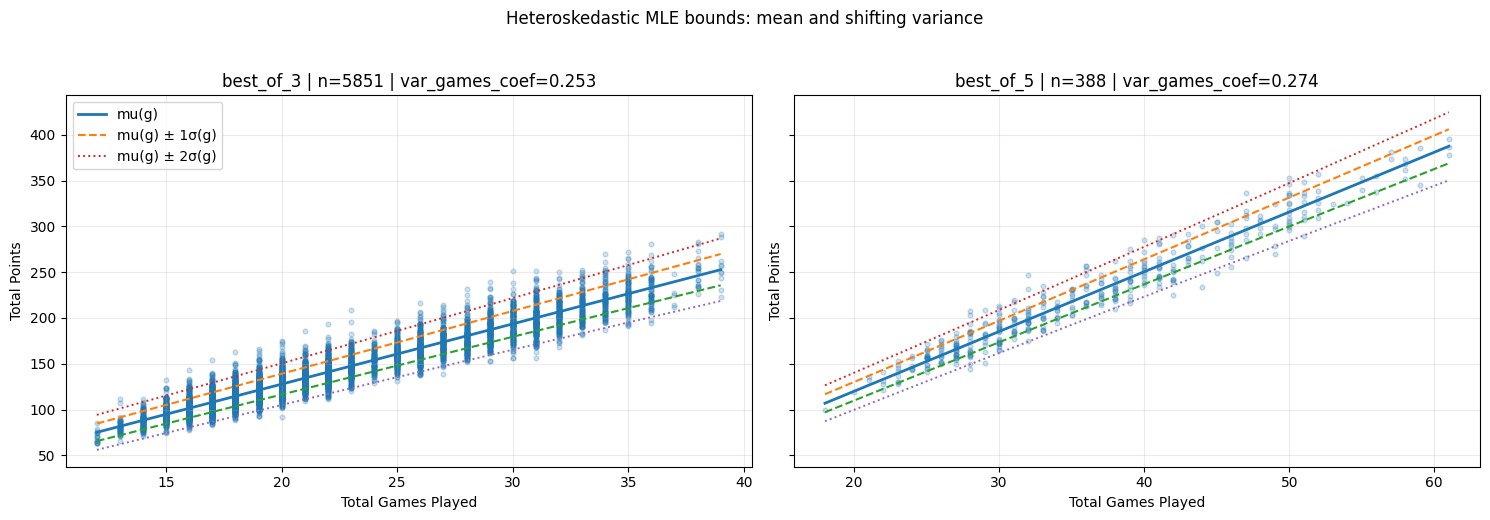

In [16]:
# Visualize heteroskedastic variance MLE bounds vs total games

REQ_FUNCS = [
    "fit_gaussian_mean_mle",
    "predict_mean",
    "fit_variance_mle_from_residuals",
    "predict_sigma",
]
for fn in REQ_FUNCS:
    if fn not in globals():
        raise ValueError(f"{fn} is not defined. Run the heteroskedastic MLE cell first.")

features = ["total_games_played", "total_aces_match", "break_rate", "total_tiebreaks_played"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.suptitle("Heteroskedastic MLE bounds: mean and shifting variance", y=1.03)

for ax, bo, label in [(axes[0], 3, "best_of_3"), (axes[1], 5, "best_of_5")]:
    # Avoid duplicate total_games_played columns in selection.
    seg_cols = features + ["total_points"]
    seg = (
        df[df["summary_mode_best_of"] == bo][seg_cols]
        .dropna()
        .copy()
    )

    X_raw = seg[features].to_numpy(dtype=float)
    y = seg["total_points"].to_numpy(dtype=float)
    g = seg["total_games_played"].to_numpy(dtype=float)

    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)

    # Step 1: mean MLE on all four features.
    beta_hat = fit_gaussian_mean_mle(X, y)
    mu = predict_mean(X, beta_hat)

    # Step 2: variance MLE on residuals using games only.
    resid = y - mu
    gamma_hat, g_mean, g_std = fit_variance_mle_from_residuals(g, resid)

    # Build smooth curves over games using mean feature profile for non-game features.
    g_grid = np.linspace(float(np.min(g)), float(np.max(g)), 240)
    mean_raw = np.mean(X_raw, axis=0)
    X_grid_raw = np.tile(mean_raw, (len(g_grid), 1))
    X_grid_raw[:, 0] = g_grid  # vary games only
    X_grid = scaler.transform(X_grid_raw)

    mu_grid = predict_mean(X_grid, beta_hat)
    sigma_grid = predict_sigma(g_grid, gamma_hat, g_mean, g_std)

    ax.scatter(g, y, s=12, alpha=0.22)
    ax.plot(g_grid, mu_grid, linewidth=2, label="mu(g)")
    ax.plot(g_grid, mu_grid + sigma_grid, linestyle="--", linewidth=1.5, label="mu(g) ± 1σ(g)")
    ax.plot(g_grid, mu_grid - sigma_grid, linestyle="--", linewidth=1.5)
    ax.plot(g_grid, mu_grid + 2.0 * sigma_grid, linestyle=":", linewidth=1.4, label="mu(g) ± 2σ(g)")
    ax.plot(g_grid, mu_grid - 2.0 * sigma_grid, linestyle=":", linewidth=1.4)

    ax.set_title(f"{label} | n={len(seg)} | var_games_coef={gamma_hat[1]:.3f}")
    ax.set_xlabel("Total Games Played")
    ax.set_ylabel("Total Points")
    ax.grid(alpha=0.25)

axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()


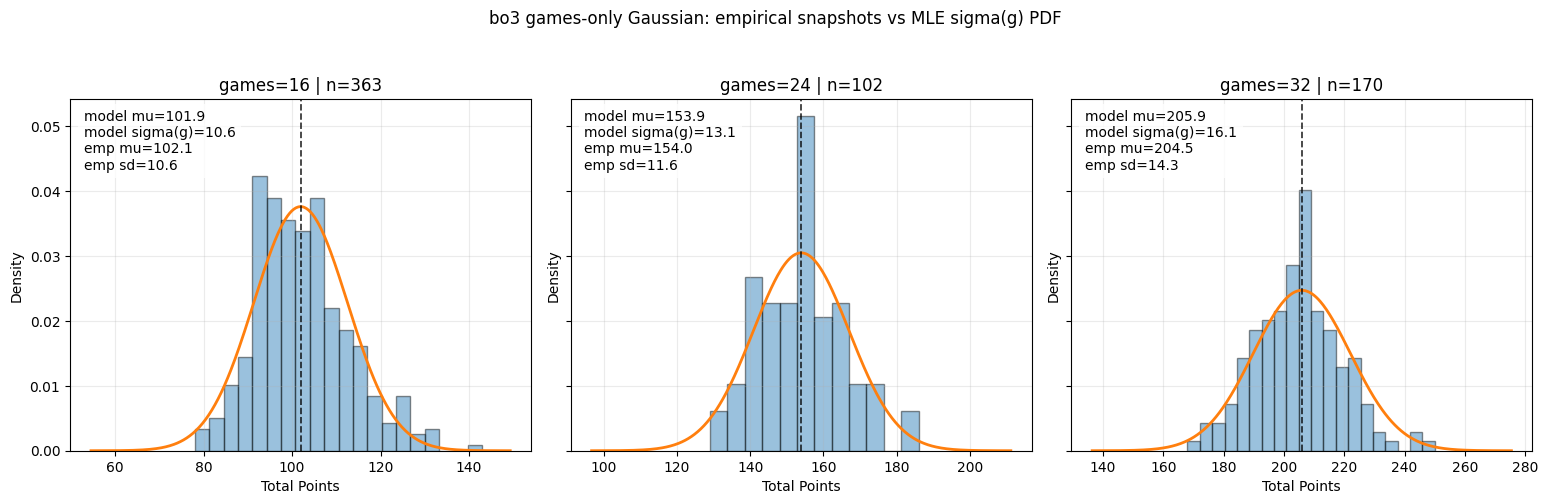

Variance-model gamma0=5.0662, gamma1=0.3080
Positive gamma1 implies wider sigma at higher games (after scaling).


In [17]:
# Model-implied Gaussian PDF check at fixed games lines (bo3)
# using heteroskedastic sigma(g) from the MLE residual-variance model.

from scipy.optimize import minimize

GAMES_LINES = [16, 24, 32]
TARGET_BO = 3

mle_pdf_df = (
    df[df["summary_mode_best_of"] == TARGET_BO][["total_games_played", "total_points"]]
    .dropna()
    .copy()
)
mle_pdf_df["total_games_played"] = pd.to_numeric(mle_pdf_df["total_games_played"], errors="coerce")
mle_pdf_df["total_points"] = pd.to_numeric(mle_pdf_df["total_points"], errors="coerce")
mle_pdf_df = mle_pdf_df.dropna(subset=["total_games_played", "total_points"]).copy()

X_all = mle_pdf_df[["total_games_played"]].to_numpy(dtype=float)
y_all = mle_pdf_df["total_points"].to_numpy(dtype=float)
g_all = mle_pdf_df["total_games_played"].to_numpy(dtype=float)

# Mean model (games-only Gaussian center)
mean_model = LinearRegression()
mean_model.fit(X_all, y_all)
mu_all = mean_model.predict(X_all)
resid_all = y_all - mu_all

# Residual variance MLE model: log(sigma^2) = gamma0 + gamma1 * scaled_games
# (same functional form as heteroskedastic section)
g_mean = float(np.mean(g_all))
g_std = float(np.std(g_all, ddof=0))
if g_std <= 0:
    g_std = 1.0
g_scaled = (g_all - g_mean) / g_std
Z = np.column_stack([np.ones(len(g_scaled)), g_scaled])

eps = 1e-6
gamma_init = np.linalg.lstsq(Z, np.log(resid_all**2 + eps), rcond=None)[0]

def var_nll(gamma: np.ndarray) -> float:
    log_var = Z @ gamma
    var = np.exp(log_var)
    return float(0.5 * np.sum(np.log(2.0 * np.pi * var) + (resid_all**2) / var))

opt = minimize(var_nll, gamma_init, method="L-BFGS-B")
gamma_hat = opt.x if opt.success else gamma_init

def sigma_of_games(games: float | np.ndarray) -> np.ndarray:
    g = np.asarray(games, dtype=float)
    g_s = (g - g_mean) / g_std
    log_var = gamma_hat[0] + gamma_hat[1] * g_s
    return np.sqrt(np.exp(log_var))

fig, axes = plt.subplots(1, len(GAMES_LINES), figsize=(5.2 * len(GAMES_LINES), 4.8), sharey=True)
fig.suptitle(
    "bo3 games-only Gaussian: empirical snapshots vs MLE sigma(g) PDF",
    y=1.04,
)

if len(GAMES_LINES) == 1:
    axes = [axes]

for ax, g in zip(axes, GAMES_LINES):
    snap = mle_pdf_df[mle_pdf_df["total_games_played"] == g]["total_points"].to_numpy(dtype=float)
    n = len(snap)

    if n < 5:
        ax.set_title(f"games={g} | n={n} (too few)")
        ax.grid(alpha=0.25)
        continue

    mu_g = float(mean_model.predict(np.array([[float(g)]]))[0])
    sigma_g = float(sigma_of_games(np.array([g]))[0])

    x_min = min(float(np.min(snap)), mu_g - 4.0 * sigma_g)
    x_max = max(float(np.max(snap)), mu_g + 4.0 * sigma_g)
    x_grid = np.linspace(x_min - 5, x_max + 5, 400)

    model_pdf = (1.0 / (sigma_g * np.sqrt(2.0 * np.pi))) * np.exp(
        -0.5 * ((x_grid - mu_g) / sigma_g) ** 2
    )

    ax.hist(snap, bins=min(20, max(8, n // 8)), density=True, alpha=0.45, edgecolor="black")
    ax.plot(x_grid, model_pdf, linewidth=2)
    ax.axvline(mu_g, linestyle="--", linewidth=1.25, color="black", alpha=0.8)

    emp_mean = float(np.mean(snap))
    emp_std = float(np.std(snap, ddof=1)) if n > 1 else np.nan

    ax.set_title(f"games={g} | n={n}")
    ax.set_xlabel("Total Points")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.25)
    ax.text(
        0.03,
        0.97,
        f"model mu={mu_g:.1f}\nmodel sigma(g)={sigma_g:.1f}\nemp mu={emp_mean:.1f}\nemp sd={emp_std:.1f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"facecolor": "white", "alpha": 0.78, "edgecolor": "none"},
    )

plt.tight_layout()
plt.show()

print(f"Variance-model gamma0={gamma_hat[0]:.4f}, gamma1={gamma_hat[1]:.4f}")
print("Positive gamma1 implies wider sigma at higher games (after scaling).")


## Presentation Plots: Best-of-3 Only

Bo3-only calibration plots (same bootstrap setup) for presenting without bo5 panels.

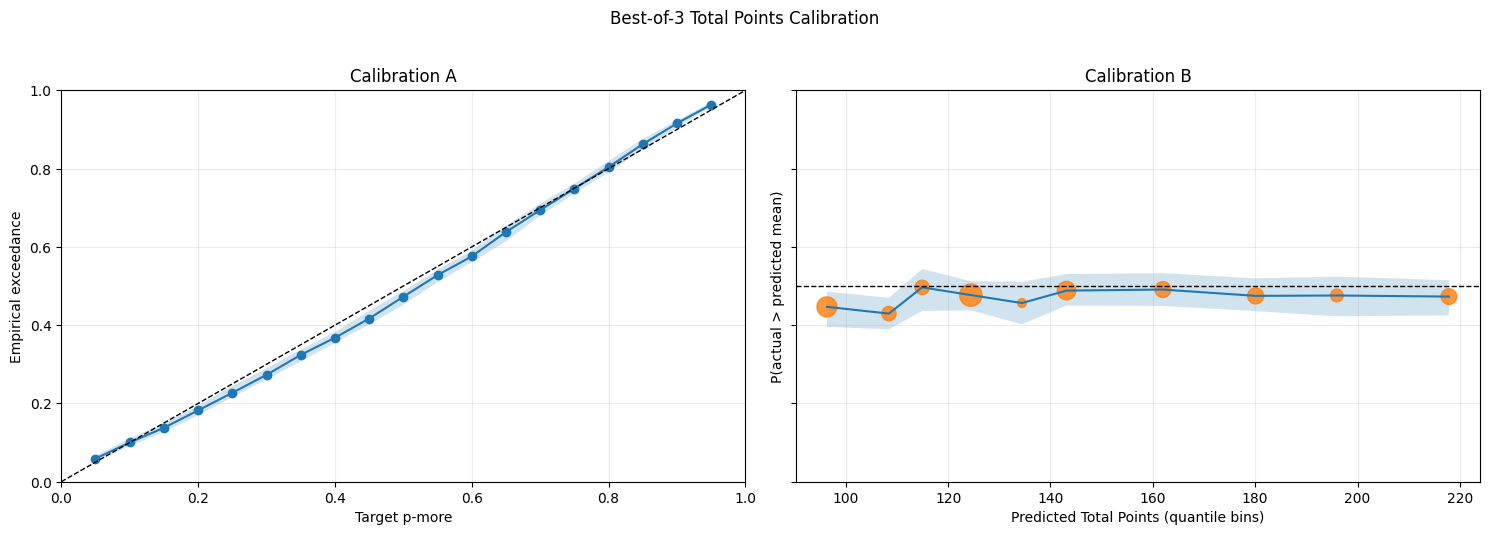

In [18]:
# bo3-only calibration presentation plots (games-only Gaussian)

if "run_repeated_calibration" not in globals():
    raise ValueError("run_repeated_calibration is not defined. Run the bootstrap calibration setup cell first.")

bo3_seg = df[df["summary_mode_best_of"] == 3].copy()
bo3_features = ["total_games_played"]
bo3_bins = 10

bo3_res = run_repeated_calibration(
    df_seg=bo3_seg,
    features=bo3_features,
    n_bins=bo3_bins,
    n_repeats=N_REPEATS,
)

# Plot both calibration views side-by-side for presentation.
fig, (axB, axC) = plt.subplots(1, 2, figsize=(15, 5.2), sharey=True)
fig.suptitle("Best-of-3 Total Points Calibration", y=1.02)

# Calibration B: empirical exceedance vs target p-more
y10_b, y50_b, y90_b = bo3_res["curve2"]["p10"], bo3_res["curve2"]["p50"], bo3_res["curve2"]["p90"]
axB.fill_between(P_MORE_GRID, y10_b, y90_b, alpha=0.2)
axB.plot(P_MORE_GRID, y50_b, marker="o", linewidth=1.5)
axB.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="black")
axB.set_xlim(0.0, 1.0)
axB.set_ylim(0.0, 1.0)
axB.set_xlabel("Target p-more")
axB.set_ylabel("Empirical exceedance")
axB.set_title("Calibration A")
axB.grid(alpha=0.25)

# Calibration C: P(actual > prediction) by predicted total points
x_c = np.asarray(bo3_res["curve3_x"], dtype=float)
y10_c, y50_c, y90_c = bo3_res["curve3"]["p10"], bo3_res["curve3"]["p50"], bo3_res["curve3"]["p90"]
n_vals_c = np.asarray(bo3_res["curve3_mean_count"], dtype=float)

if len(n_vals_c) > 0 and np.nanmax(n_vals_c) > np.nanmin(n_vals_c):
    sizes_c = 40 + 220 * ((n_vals_c - np.nanmin(n_vals_c)) / (np.nanmax(n_vals_c) - np.nanmin(n_vals_c)))
else:
    sizes_c = np.full(len(x_c), 120.0)

axC.fill_between(x_c, y10_c, y90_c, alpha=0.2)
axC.plot(x_c, y50_c, linewidth=1.5)
axC.scatter(x_c, y50_c, s=sizes_c, alpha=0.8)
axC.axhline(0.5, linestyle="--", linewidth=1, color="black")
axC.set_ylim(0.0, 1.0)
axC.set_xlabel("Predicted Total Points (quantile bins)")
axC.set_ylabel("P(actual > predicted mean)")
axC.set_title("Calibration B")
axC.grid(alpha=0.25)

plt.tight_layout()
plt.show()


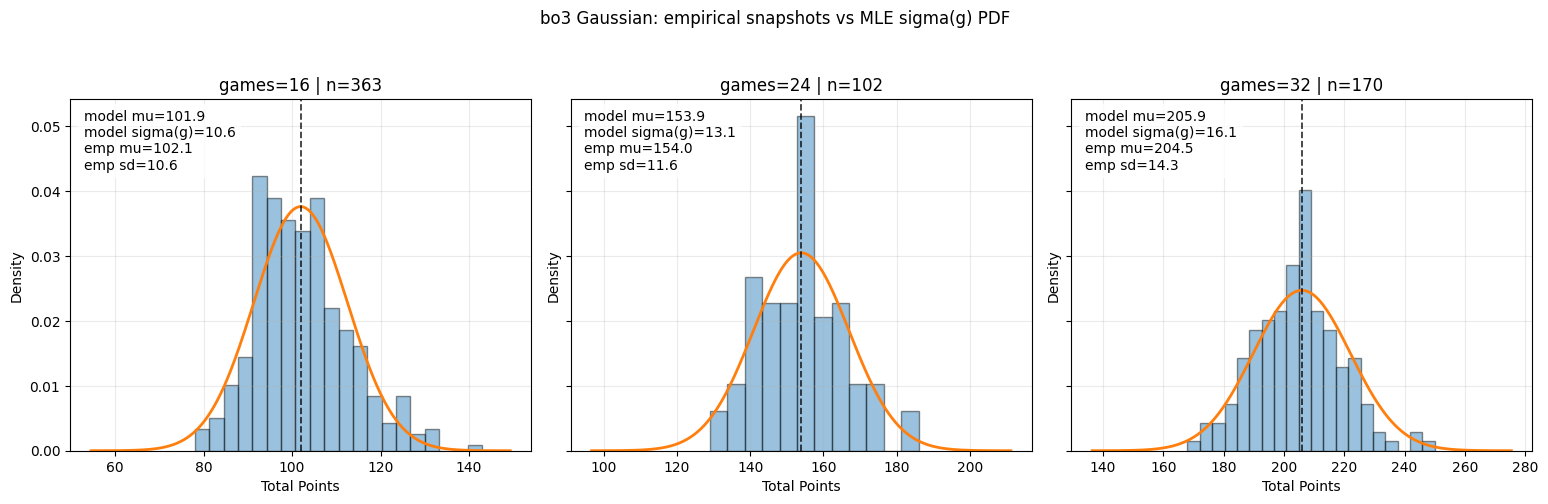

Variance-model gamma0=5.0662, gamma1=0.3080
Positive gamma1 implies wider sigma at higher games (after scaling).


In [19]:
# Model-implied Gaussian PDF check at fixed games lines (bo3)
# using heteroskedastic sigma(g) from the MLE residual-variance model.

from scipy.optimize import minimize

GAMES_LINES = [16, 24, 32]
TARGET_BO = 3

mle_pdf_df = (
    df[df["summary_mode_best_of"] == TARGET_BO][["total_games_played", "total_points"]]
    .dropna()
    .copy()
)
mle_pdf_df["total_games_played"] = pd.to_numeric(mle_pdf_df["total_games_played"], errors="coerce")
mle_pdf_df["total_points"] = pd.to_numeric(mle_pdf_df["total_points"], errors="coerce")
mle_pdf_df = mle_pdf_df.dropna(subset=["total_games_played", "total_points"]).copy()

X_all = mle_pdf_df[["total_games_played"]].to_numpy(dtype=float)
y_all = mle_pdf_df["total_points"].to_numpy(dtype=float)
g_all = mle_pdf_df["total_games_played"].to_numpy(dtype=float)

# Mean model (games-only Gaussian center)
mean_model = LinearRegression()
mean_model.fit(X_all, y_all)
mu_all = mean_model.predict(X_all)
resid_all = y_all - mu_all

# Residual variance MLE model: log(sigma^2) = gamma0 + gamma1 * scaled_games
# (same functional form as heteroskedastic section)
g_mean = float(np.mean(g_all))
g_std = float(np.std(g_all, ddof=0))
if g_std <= 0:
    g_std = 1.0
g_scaled = (g_all - g_mean) / g_std
Z = np.column_stack([np.ones(len(g_scaled)), g_scaled])

eps = 1e-6
gamma_init = np.linalg.lstsq(Z, np.log(resid_all**2 + eps), rcond=None)[0]

def var_nll(gamma: np.ndarray) -> float:
    log_var = Z @ gamma
    var = np.exp(log_var)
    return float(0.5 * np.sum(np.log(2.0 * np.pi * var) + (resid_all**2) / var))

opt = minimize(var_nll, gamma_init, method="L-BFGS-B")
gamma_hat = opt.x if opt.success else gamma_init

def sigma_of_games(games: float | np.ndarray) -> np.ndarray:
    g = np.asarray(games, dtype=float)
    g_s = (g - g_mean) / g_std
    log_var = gamma_hat[0] + gamma_hat[1] * g_s
    return np.sqrt(np.exp(log_var))

fig, axes = plt.subplots(1, len(GAMES_LINES), figsize=(5.2 * len(GAMES_LINES), 4.8), sharey=True)
fig.suptitle(
    "bo3 Gaussian: empirical snapshots vs MLE sigma(g) PDF",
    y=1.04,
)

if len(GAMES_LINES) == 1:
    axes = [axes]

for ax, g in zip(axes, GAMES_LINES):
    snap = mle_pdf_df[mle_pdf_df["total_games_played"] == g]["total_points"].to_numpy(dtype=float)
    n = len(snap)

    if n < 5:
        ax.set_title(f"games={g} | n={n} (too few)")
        ax.grid(alpha=0.25)
        continue

    mu_g = float(mean_model.predict(np.array([[float(g)]]))[0])
    sigma_g = float(sigma_of_games(np.array([g]))[0])

    x_min = min(float(np.min(snap)), mu_g - 4.0 * sigma_g)
    x_max = max(float(np.max(snap)), mu_g + 4.0 * sigma_g)
    x_grid = np.linspace(x_min - 5, x_max + 5, 400)

    model_pdf = (1.0 / (sigma_g * np.sqrt(2.0 * np.pi))) * np.exp(
        -0.5 * ((x_grid - mu_g) / sigma_g) ** 2
    )

    ax.hist(snap, bins=min(20, max(8, n // 8)), density=True, alpha=0.45, edgecolor="black")
    ax.plot(x_grid, model_pdf, linewidth=2)
    ax.axvline(mu_g, linestyle="--", linewidth=1.25, color="black", alpha=0.8)

    emp_mean = float(np.mean(snap))
    emp_std = float(np.std(snap, ddof=1)) if n > 1 else np.nan

    ax.set_title(f"games={g} | n={n}")
    ax.set_xlabel("Total Points")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.25)
    ax.text(
        0.03,
        0.97,
        f"model mu={mu_g:.1f}\nmodel sigma(g)={sigma_g:.1f}\nemp mu={emp_mean:.1f}\nemp sd={emp_std:.1f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"facecolor": "white", "alpha": 0.78, "edgecolor": "none"},
    )

plt.tight_layout()
plt.show()

print(f"Variance-model gamma0={gamma_hat[0]:.4f}, gamma1={gamma_hat[1]:.4f}")
print("Positive gamma1 implies wider sigma at higher games (after scaling).")


## Joint-Fit Gaussian MLE Calibration (bo3 + bo5)

Compare joint-fit Gaussian MLE calibration for:
- games-only (`total_games_played`)
- all-four features (`total_games_played`, `total_aces_match`, `break_rate`, `total_tiebreaks_played`)

Plots shown: Calibration B and Calibration C for both bo3 and bo5.

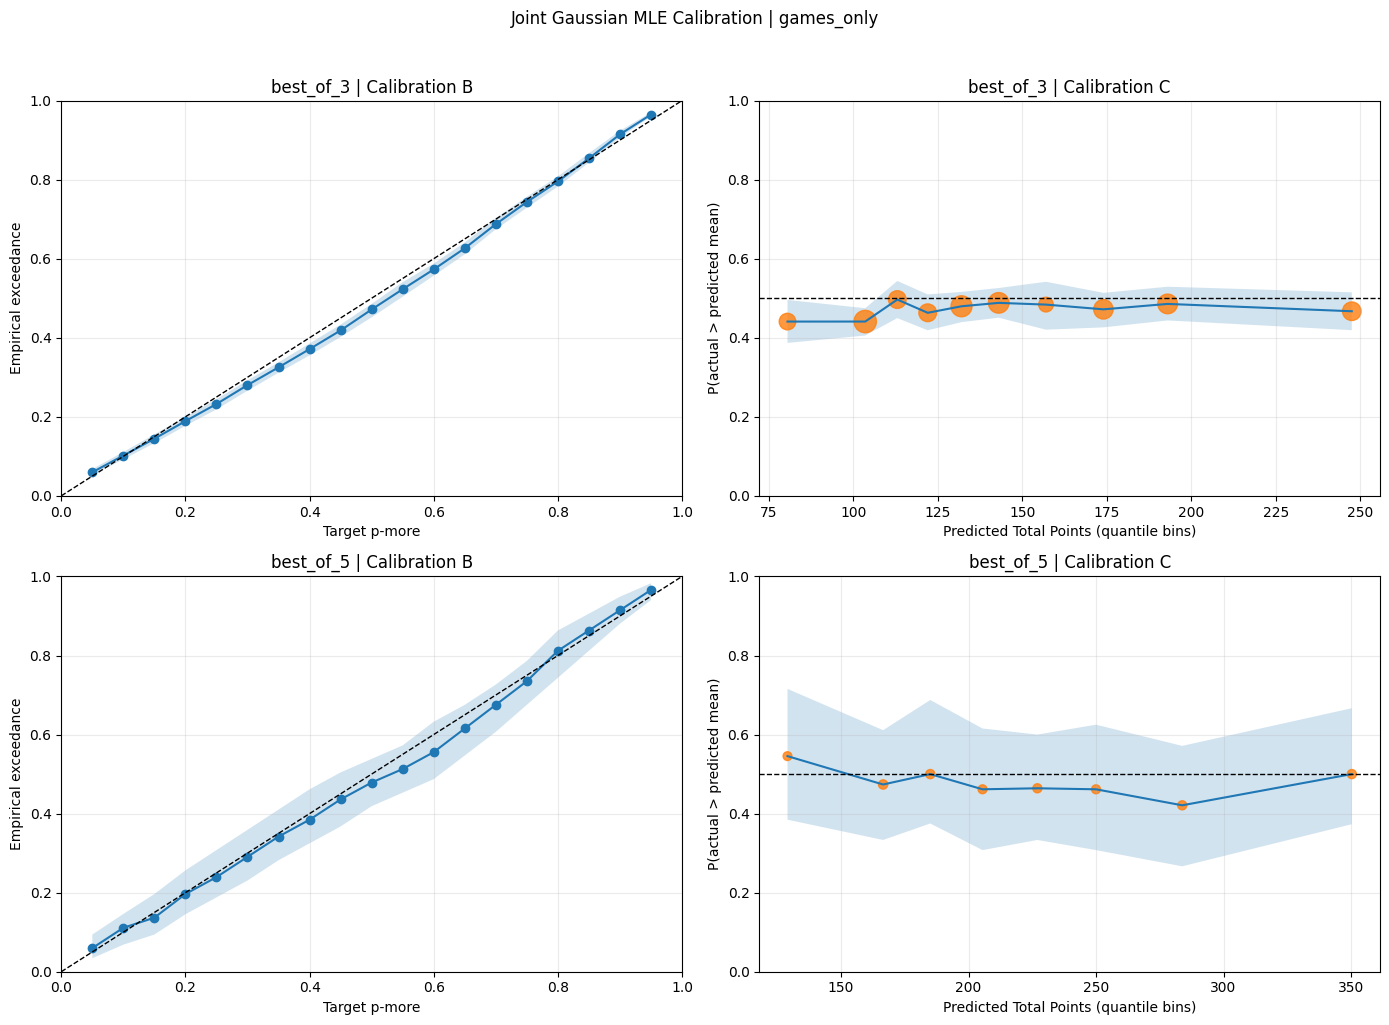

games_only: bo3 n_boot=500, bo5 n_boot=500


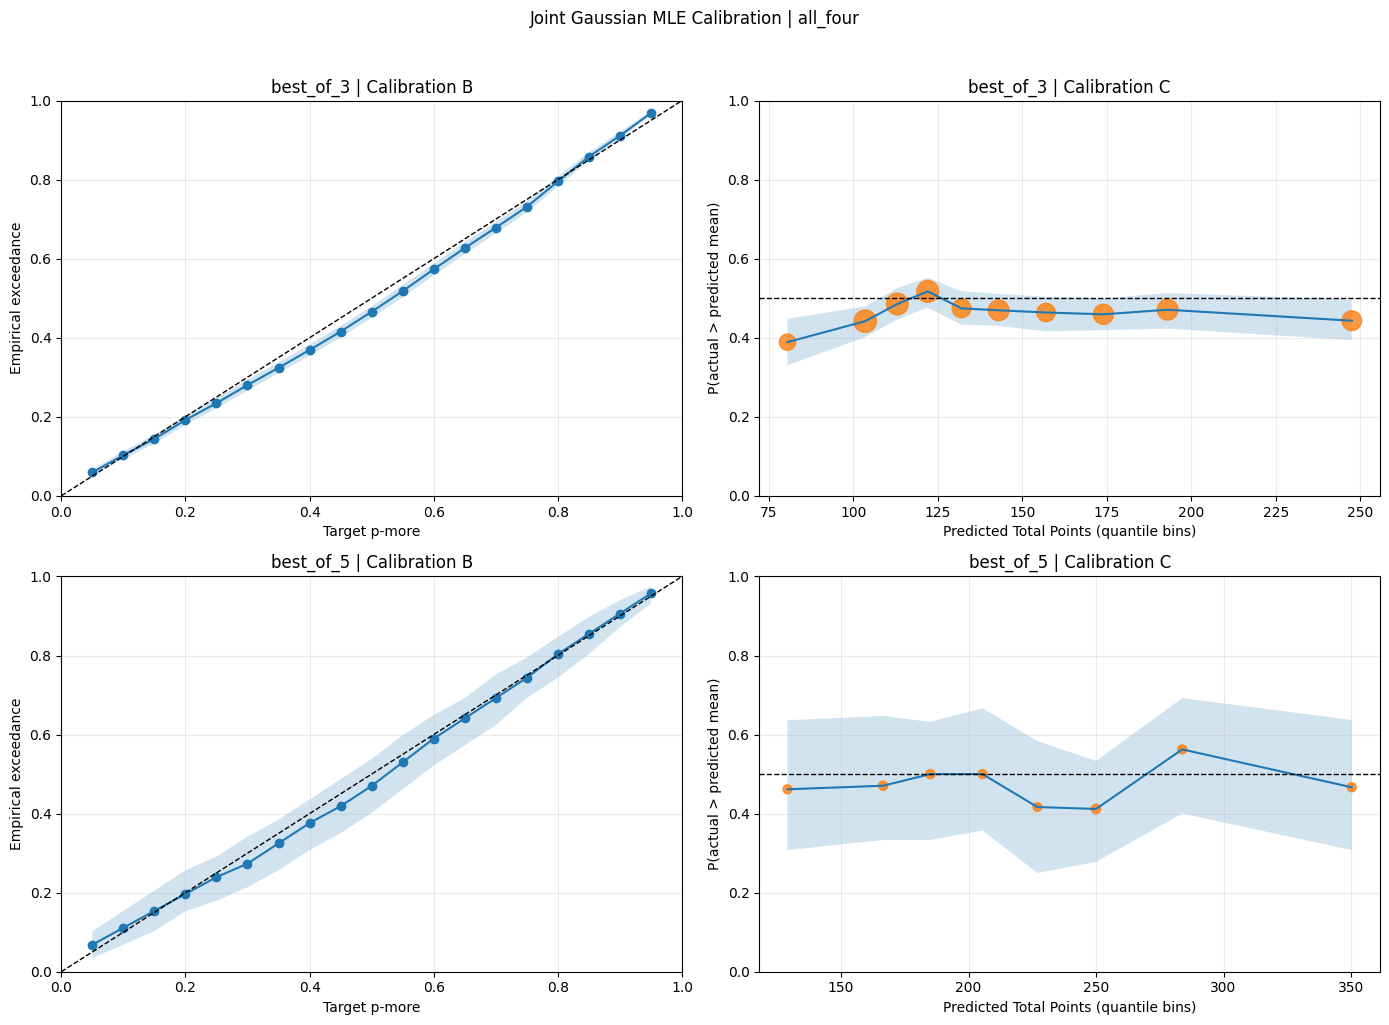

all_four: bo3 n_boot=500, bo5 n_boot=500


In [20]:
# Joint-fit Gaussian MLE calibration (bo3 + bo5) for games-only and all-four

from scipy import optimize
from sklearn.preprocessing import StandardScaler

if "quantile_edges" not in globals() or "P_MORE_GRID" not in globals():
    raise ValueError("Run calibration setup cells first (quantile_edges and P_MORE_GRID required).")

N_REPEATS_JOINT = N_REPEATS if "N_REPEATS" in globals() else 100
TEST_SIZE_JOINT = TEST_SIZE if "TEST_SIZE" in globals() else 0.3


def fit_joint_gaussian_mle(X: np.ndarray, y: np.ndarray, epsilon: float = 1e-6) -> np.ndarray:
    n_features = X.shape[1]

    mean_intercept_init = float(np.mean(y))
    mean_coeffs_init = np.zeros(n_features, dtype=float)
    residuals = y - mean_intercept_init
    residual_var = float(np.var(residuals))
    log_sigma_intercept_init = 0.5 * np.log(max(residual_var, epsilon**2))
    log_sigma_coeffs_init = np.zeros(n_features, dtype=float)

    init = np.concatenate([
        np.array([mean_intercept_init], dtype=float),
        mean_coeffs_init,
        np.array([log_sigma_intercept_init], dtype=float),
        log_sigma_coeffs_init,
    ])

    def unpack(params: np.ndarray) -> tuple[float, np.ndarray, float, np.ndarray]:
        mean_intercept = float(params[0])
        mean_coeffs = params[1 : 1 + n_features]
        log_sigma_intercept = float(params[1 + n_features])
        log_sigma_coeffs = params[2 + n_features :]
        return mean_intercept, mean_coeffs, log_sigma_intercept, log_sigma_coeffs

    def nll(params: np.ndarray) -> float:
        mean_intercept, mean_coeffs, log_sigma_intercept, log_sigma_coeffs = unpack(params)
        mu = mean_intercept + X @ mean_coeffs
        log_sigma = log_sigma_intercept + X @ log_sigma_coeffs
        sigma = np.maximum(np.exp(log_sigma), epsilon)

        ll = (
            -0.5 * np.log(2 * np.pi)
            - np.log(sigma)
            - ((y - mu) ** 2) / (2 * sigma**2)
        )
        return float(-np.sum(ll))

    result = optimize.minimize(nll, init, method="L-BFGS-B")
    if not result.success:
        raise ValueError(f"Joint MLE optimization failed: {result.message}")
    return result.x


def predict_joint_gaussian(params: np.ndarray, X: np.ndarray, epsilon: float = 1e-6) -> tuple[np.ndarray, np.ndarray]:
    n_features = X.shape[1]
    mean_intercept = float(params[0])
    mean_coeffs = params[1 : 1 + n_features]
    log_sigma_intercept = float(params[1 + n_features])
    log_sigma_coeffs = params[2 + n_features :]

    mu = mean_intercept + X @ mean_coeffs
    sigma = np.maximum(np.exp(log_sigma_intercept + X @ log_sigma_coeffs), epsilon)
    return mu, sigma


def run_joint_mle_calibration(df_seg: pd.DataFrame, features: list[str], n_bins: int, n_repeats: int) -> dict:
    data = df_seg.dropna(subset=features + ["total_points", "total_games_played"]).copy()
    X_raw = data[features].to_numpy(dtype=float)
    y = data["total_points"].to_numpy(dtype=float)

    strat_edges = quantile_edges(data["total_games_played"], n_bins=n_bins)
    strat_bins = pd.cut(data["total_games_played"], bins=strat_edges, include_lowest=True, labels=False)
    if strat_bins.isna().any():
        raise ValueError("Unable to assign one or more rows to stratification bins.")
    strat_bins = strat_bins.astype(int)
    can_stratify = strat_bins.value_counts(dropna=False).min() >= 2 and strat_bins.nunique() > 1

    pred_edges = quantile_edges(data["total_points"], n_bins=n_bins)
    pred_mids = (pred_edges[:-1] + pred_edges[1:]) / 2.0
    n_pred_bins = len(pred_mids)

    curve_b_samples = []
    curve_c_samples = []
    curve_c_counts = []

    for r in range(n_repeats):
        split_kwargs = {"test_size": TEST_SIZE_JOINT, "random_state": 50000 + r}
        if can_stratify:
            split_kwargs["stratify"] = strat_bins

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, **split_kwargs)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        try:
            params = fit_joint_gaussian_mle(X_train, y_train)
        except ValueError:
            continue

        mu_test, sigma_test = predict_joint_gaussian(params, X_test)

        # Calibration B
        exceed_vals = []
        for p_more in P_MORE_GRID:
            z = normal.inv_cdf(1.0 - float(p_more))
            threshold = mu_test + sigma_test * z
            exceed_vals.append(float((y_test > threshold).mean()))
        curve_b_samples.append(np.array(exceed_vals, dtype=float))

        # Calibration C
        test_df = pd.DataFrame({"pred": mu_test, "actual": y_test})
        test_df["bin_id"] = pd.cut(test_df["pred"], bins=pred_edges, include_lowest=True, labels=False)
        test_df["above"] = (test_df["actual"] > test_df["pred"]).astype(float)

        grouped = test_df.groupby("bin_id", dropna=False)["above"].agg(["mean", "size"]).rename(
            columns={"mean": "pct", "size": "n"}
        )

        c_vals = np.full(n_pred_bins, np.nan)
        n_vals = np.zeros(n_pred_bins)
        for b in range(n_pred_bins):
            if b in grouped.index and pd.notna(grouped.loc[b, "pct"]):
                c_vals[b] = float(grouped.loc[b, "pct"])
                n_vals[b] = float(grouped.loc[b, "n"])

        curve_c_samples.append(c_vals)
        curve_c_counts.append(n_vals)

    if len(curve_b_samples) == 0:
        raise ValueError("No successful MLE bootstrap iterations. Try reducing repeats or checking segment data.")

    b_arr = np.vstack(curve_b_samples)
    c_arr = np.vstack(curve_c_samples)
    n_arr = np.vstack(curve_c_counts)

    return {
        "curve_b": {
            "p10": np.nanpercentile(b_arr, 10, axis=0),
            "p50": np.nanpercentile(b_arr, 50, axis=0),
            "p90": np.nanpercentile(b_arr, 90, axis=0),
        },
        "curve_c_x": pred_mids,
        "curve_c": {
            "p10": np.nanpercentile(c_arr, 10, axis=0),
            "p50": np.nanpercentile(c_arr, 50, axis=0),
            "p90": np.nanpercentile(c_arr, 90, axis=0),
        },
        "curve_c_mean_count": np.nanmean(n_arr, axis=0),
        "n_boot_used": int(len(curve_b_samples)),
    }


scenarios = {
    "games_only": ["total_games_played"],
    "all_four": ["total_games_played", "total_aces_match", "break_rate", "total_tiebreaks_played"],
}

for scenario_name, feature_cols in scenarios.items():
    payload = {}
    for segment_label, bo, n_bins in [("best_of_3", 3, 10), ("best_of_5", 5, 8)]:
        seg = df[df["summary_mode_best_of"] == bo].copy()
        payload[segment_label] = run_joint_mle_calibration(
            df_seg=seg,
            features=feature_cols,
            n_bins=n_bins,
            n_repeats=N_REPEATS_JOINT,
        )

    # Shared marker size scale across bo3 and bo5 for Calibration C.
    combined_counts = np.concatenate([
        np.asarray(payload["best_of_3"]["curve_c_mean_count"], dtype=float),
        np.asarray(payload["best_of_5"]["curve_c_mean_count"], dtype=float),
    ])
    valid_counts = combined_counts[np.isfinite(combined_counts)]
    min_count = float(np.min(valid_counts)) if len(valid_counts) > 0 else np.nan
    max_count = float(np.max(valid_counts)) if len(valid_counts) > 0 else np.nan

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey="col")
    fig.suptitle(f"Joint Gaussian MLE Calibration | {scenario_name}", y=1.02)

    for row_idx, segment_label in enumerate(["best_of_3", "best_of_5"]):
        res = payload[segment_label]

        # Calibration B
        ax_b = axes[row_idx, 0]
        b10, b50, b90 = res["curve_b"]["p10"], res["curve_b"]["p50"], res["curve_b"]["p90"]
        ax_b.fill_between(P_MORE_GRID, b10, b90, alpha=0.2)
        ax_b.plot(P_MORE_GRID, b50, marker="o", linewidth=1.5)
        ax_b.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="black")
        ax_b.set_xlim(0.0, 1.0)
        ax_b.set_ylim(0.0, 1.0)
        ax_b.set_xlabel("Target p-more")
        ax_b.set_ylabel("Empirical exceedance")
        ax_b.set_title(f"{segment_label} | Calibration B")
        ax_b.grid(alpha=0.25)

        # Calibration C
        ax_c = axes[row_idx, 1]
        x = np.asarray(res["curve_c_x"], dtype=float)
        c10, c50, c90 = res["curve_c"]["p10"], res["curve_c"]["p50"], res["curve_c"]["p90"]
        n_vals = np.asarray(res["curve_c_mean_count"], dtype=float)

        if np.isfinite(min_count) and np.isfinite(max_count) and max_count > min_count:
            sizes = 40 + 220 * ((n_vals - min_count) / (max_count - min_count))
        else:
            sizes = np.full(len(x), 120.0)

        ax_c.fill_between(x, c10, c90, alpha=0.2)
        ax_c.plot(x, c50, linewidth=1.5)
        ax_c.scatter(x, c50, s=sizes, alpha=0.8)
        ax_c.axhline(0.5, linestyle="--", linewidth=1, color="black")
        ax_c.set_ylim(0.0, 1.0)
        ax_c.set_xlabel("Predicted Total Points (quantile bins)")
        ax_c.set_ylabel("P(actual > predicted mean)")
        ax_c.set_title(f"{segment_label} | Calibration C")
        ax_c.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    print(
        f"{scenario_name}: bo3 n_boot={payload['best_of_3']['n_boot_used']}, "
        f"bo5 n_boot={payload['best_of_5']['n_boot_used']}"
    )


In [ ]:
# Joint-fit Gaussian MLE bounds vs total games (bo3 + bo5)

from sklearn.preprocessing import StandardScaler

if "fit_joint_gaussian_mle" not in globals() or "predict_joint_gaussian" not in globals():
    raise ValueError("Run the joint-fit Gaussian MLE calibration cell first.")

joint_features = ["total_games_played", "total_aces_match", "break_rate", "total_tiebreaks_played"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.suptitle("Joint-Fit Gaussian MLE bounds: mean and shifting variance", y=1.03)

for ax, bo, label in [(axes[0], 3, "best_of_3"), (axes[1], 5, "best_of_5")]:
    seg = (
        df[df["summary_mode_best_of"] == bo][joint_features + ["total_points"]]
        .dropna()
        .copy()
    )

    X_raw = seg[joint_features].to_numpy(dtype=float)
    y = seg["total_points"].to_numpy(dtype=float)
    g = seg["total_games_played"].to_numpy(dtype=float)

    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)

    params = fit_joint_gaussian_mle(X, y)
    mu, sigma = predict_joint_gaussian(params, X)

    # Build smooth game-axis curves by holding non-game features at segment mean.
    g_grid = np.linspace(float(np.min(g)), float(np.max(g)), 240)
    mean_raw = np.mean(X_raw, axis=0)
    X_grid_raw = np.tile(mean_raw, (len(g_grid), 1))
    X_grid_raw[:, 0] = g_grid
    X_grid = scaler.transform(X_grid_raw)

    mu_grid, sigma_grid = predict_joint_gaussian(params, X_grid)

    n_features = X.shape[1]
    log_sigma_coef_games_std = float(params[2 + n_features])

    ax.scatter(g, y, s=12, alpha=0.22)
    ax.plot(g_grid, mu_grid, linewidth=2, label="mu(g)")
    ax.plot(g_grid, mu_grid + sigma_grid, linestyle="--", linewidth=1.5, label="mu(g) ± 1σ(g)")
    ax.plot(g_grid, mu_grid - sigma_grid, linestyle="--", linewidth=1.5)
    ax.plot(g_grid, mu_grid + 2.0 * sigma_grid, linestyle=":", linewidth=1.4, label="mu(g) ± 2σ(g)")
    ax.plot(g_grid, mu_grid - 2.0 * sigma_grid, linestyle=":", linewidth=1.4)

    ax.set_title(
        f"{label} | n={len(seg)} | log_sigma_games_coef_std={log_sigma_coef_games_std:.3f}"
    )
    ax.set_xlabel("Total Games Played")
    ax.set_ylabel("Total Points")
    ax.grid(alpha=0.25)

axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()
